In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import pickle 
import seaborn as sns
import random
import matplotlib.pyplot as plt
import os.path
import operator
from itertools import combinations
from random import randint
from datetime import datetime
import copy
import sim
import sim_crp
from collections import Counter
sns.set_context('talk',font_scale=1.0)


In [2]:
def load_data(cond,seed):
    file = open('../pickled_exp_parms/condition_'+cond+'_'+str(seed)+'.pkl','rb')
    data= pickle.load(file)
    exp_struc = data[0]
    rho0 = data[1]
    all_decay = data[2]
    file.close()
    return exp_struc,rho0, all_decay

def load_mdp(seed):
    file = open('../pickled_exp_parms/mdp_'+str(seed)+'.pkl','rb')
    data= pickle.load(file)
    all_change_points = data[0]
    all_n_cp = data[1]
    all_next_galaxy = data[2]
    all_counter = data[3]
    file.close()
    return all_change_points, all_n_cp, all_next_galaxy, all_counter

def flatten_list(list):
    new_list = [item for sublist in list for item in sublist]
    return new_list


In [4]:
params=[0.01,0.5]
cond_num=6
num_particles=100
choices, all_reward_exp,true_planet = sim_crp.crp(params,cond_num,num_particles)


[0.01, 0.5]
decay_mu: 0.5000000000000001
decay_var: 0.10000000000000003
v_stay_mu: 46.962765331008754
v_stay_var: 882.2005310141592
v_leave_mu: 36.52659525745125
v_leave_var: 14.204787044564375
prob stay: 0.6362936007518832
decay_mu: 0.49999999999999944
decay_var: 0.10000000000000087
v_stay_mu: 32.44572381973339
v_stay_var: 421.0899976745704
v_leave_mu: 44.468753924415616
v_leave_var: 12.451251098836371
prob stay: 0.2818247854560494
decay_mu: 0.6592904023682189
decay_var: 0.017220187234701645
v_stay_mu: 64.83326858687812
v_stay_var: 166.52528921483358
v_leave_mu: 36.73641875420024
v_leave_var: 5.248059822028606
prob stay: 0.9839746464995629
decay_mu: 0.6538237440398589
decay_var: 0.020903073787036708
v_stay_mu: 46.74616550477006
v_stay_var: 106.8515341069539
v_leave_mu: 41.081439652312746
v_leave_var: 5.135179956539093
prob stay: 0.703778106167562
decay_mu: 0.6572403449110521
decay_var: 0.018608683879725862
v_stay_mu: 36.10148362978875
v_stay_var: 56.14580702180503
v_leave_mu: 42.62004

decay_mu: 0.6892586201338304
decay_var: 0.010305400193845182
v_stay_mu: 65.0951588969484
v_stay_var: 91.91742130414401
v_leave_mu: 37.127605101109076
v_leave_var: 0.36553197708546203
prob stay: 0.9982006205126048
decay_mu: 0.6881903566201711
decay_var: 0.010991893136146735
v_stay_mu: 45.34765523472696
v_stay_var: 47.72709537299418
v_leave_mu: 37.40805798396566
v_leave_var: 0.36470251516401064
prob stay: 0.8738722018544143
decay_mu: 0.6892431643471454
decay_var: 0.010315264345456654
v_stay_mu: 31.1777897533253
v_stay_var: 21.10697884353916
v_leave_mu: 37.48362671055608
v_leave_var: 0.3619108785846794
prob stay: 0.08676683767380011
decay_mu: 0.6916566464544406
decay_var: 0.010295286658884018
v_stay_mu: 75.04441287952513
v_stay_var: 121.197611927471
v_leave_mu: 37.296563407669666
v_leave_var: 0.3485660131557913
prob stay: 0.9996913577216332
decay_mu: 0.6898647481580475
decay_var: 0.011302375805905596
v_stay_mu: 53.78680569436268
v_stay_var: 68.70579088453825
v_leave_mu: 37.673143146627396

decay_mu: 0.5827072678287002
decay_var: 0.02753653993902927
v_stay_mu: 53.94413133695452
v_stay_var: 235.99179688991876
v_leave_mu: 35.415865056901694
v_leave_var: 0.182019864462784
prob stay: 0.8860225107858586
decay_mu: 0.6390288197709001
decay_var: 0.0149303364601171
v_stay_mu: 38.04711369096607
v_stay_var: 52.92637348152295
v_leave_mu: 35.53921179931467
v_leave_var: 0.18171985580365427
prob stay: 0.6346280191295809
decay_mu: 0.6552864308733685
decay_var: 0.010310940759887144
v_stay_mu: 21.611913838137763
v_stay_var: 11.215597017734629
v_leave_mu: 35.5261969577557
v_leave_var: 0.18072919963974557
prob stay: 1.8802771800330298e-05
decay_mu: 0.6506081078926974
decay_var: 0.010314751067549754
v_stay_mu: 64.61129939175748
v_stay_var: 101.7271223464767
v_leave_mu: 35.41372189040357
v_leave_var: 0.17706860945201783
prob stay: 0.99808813945586
decay_mu: 0.6488019708863473
decay_var: 0.010934280568548171
v_stay_mu: 37.51326582335456
v_stay_var: 36.55406178835639
v_leave_mu: 35.5251923517959

decay_mu: 0.6474624318933837
decay_var: 0.010391673838754556
v_stay_mu: 66.0984237378463
v_stay_var: 108.30252067305896
v_leave_mu: 35.73828141733828
v_leave_var: 0.12679572727894978
prob stay: 0.9982250689381618
decay_mu: 0.6465102121826526
decay_var: 0.010959294292688493
v_stay_mu: 37.998881999736014
v_stay_var: 37.85937574583484
v_leave_mu: 35.819725697627426
v_leave_var: 0.12663539388050102
prob stay: 0.6381697637796658
decay_mu: 0.6472843066638561
decay_var: 0.010472287408645753
v_stay_mu: 22.441237280826165
v_stay_var: 12.587659680346592
v_leave_mu: 35.81567473362109
v_leave_var: 0.12617499906157403
prob stay: 8.80951479871328e-05
decay_mu: 0.6519627031508328
decay_var: 0.010504567207174687
v_stay_mu: 65.57752343855816
v_stay_var: 106.27783118560077
v_leave_mu: 35.7383585968405
v_leave_var: 0.12440005478760992
prob stay: 0.9980905902969458
decay_mu: 0.6498272521155007
decay_var: 0.011291297864074568
v_stay_mu: 33.72178428598811
v_stay_var: 30.40668779024573
v_leave_mu: 35.7943971

decay_mu: 0.6402372585110057
decay_var: 0.01131243818957467
v_stay_mu: 70.85768774583624
v_stay_var: 138.5633208130099
v_leave_mu: 35.83155842954762
v_leave_var: 0.09813024609031037
prob stay: 0.9985326776510647
decay_mu: 0.51212901620849
decay_var: 0.026256280166295054
v_stay_mu: 19.826493539019747
v_stay_var: 39.35195001653438
v_leave_mu: 35.83943051117589
v_leave_var: 0.09788373530168991
prob stay: 0.005394475901404294
decay_mu: 0.5109685966144372
decay_var: 0.025659869108865974
v_stay_mu: 52.77786987052742
v_stay_var: 273.75983660899703
v_leave_mu: 35.78642804503031
v_leave_var: 0.09683223668929732
prob stay: 0.8477330501884948
decay_mu: 0.6390220739621713
decay_var: 0.011220294351942106
v_stay_mu: 43.164597423640025
v_stay_var: 51.19504382384588
v_leave_mu: 35.87213748403422
v_leave_var: 0.09680222142954494
prob stay: 0.8457178942758449
decay_mu: 0.6429710430221602
decay_var: 0.010196545693876624
v_stay_mu: 34.687585470204155
v_stay_var: 29.676889671826316
v_leave_mu: 35.920787000

# make sure we can differentiate

In [61]:
def make_crp_sub_df(params,cond_num,sub_num):
    cluster_var = params[0]
    hyper_mu = params[1]
    num_particles = 100
    choices, all_reward_exp,true_planet = sim_crp.crp(params,cond_num,num_particles)
    prts =  [sim_crp.get_prts(block) for block in choices]
    exp_struc, __,__ = load_data(sim_crp.condition_type(cond_num),196855274)
    sub_df = pd.DataFrame(columns=['sub_num','cond_num','cluster_var','hyper_mu','block','galaxy','prt'])
    for block in range(5):
        n_planets = len(prts[block])
        tmp = pd.DataFrame({'sub_num':[sub_num]*n_planets,'cond_num':[cond_num]*n_planets,
                            'cluster_var':[cluster_var]*n_planets,'hyper_mu':[hyper_mu]*n_planets,
                           'block':[block]*n_planets,'galaxy':flatten_list(exp_struc[block])[:n_planets],
                           'prt':prts[block]})
        sub_df = pd.concat([sub_df,tmp])
        
    sub_df['reward'] = all_reward_exp
    sub_df['true_planet'] = true_planet
    sub_df['opt_prt'],__,__,__,__ = sim.get_indiv_sub_prt(cond_num,true_planet,all_reward_exp)
    sub_df['opt_prt_om'],__,__,__,__ = sim.get_indiv_sub_prt_omniscent(cond_num,true_planet,all_reward_exp)

    return sub_df

def make_crp_df(n_subs):
    sub_n = 0
    df = pd.DataFrame(columns=['sub_num','cond_num','cluster_var','hyper_mu','block','galaxy','prt','reward','true_planet','opt_prt','opt_prt_om'])
    for sub in range(n_subs):
        cluster_var = min(stats.halfnorm.rvs(loc=0.00001,scale=0.01,size=1)[0],0.1)
        hyper_mu = max(min(stats.norm.rvs(loc=0.5,scale=0.1,size=1)[0],1),0.001)
        for cond in [1,2,5,6]:
            params = [cluster_var,hyper_mu]
            sub_df = make_crp_sub_df(params,cond,sub_n)
            df = pd.concat([df,sub_df])
            sub_n += 1
    return df


def make_bayes_sub_df(params,cond_num,sub_num):
    hyper_mu = params[0]
    hyper_var = params[1]
    choices, all_reward_exp,true_planet = sim_crp.bayes(params,cond_num)
    prts =  [sim_crp.get_prts(block) for block in choices]
    exp_struc, __,__ = load_data(sim_crp.condition_type(cond_num),196855274)
    sub_df = pd.DataFrame(columns=['sub_num','cond_num','hyper_mu','hyper_var','block','galaxy','prt'])
    for block in range(5):
        n_planets = len(prts[block])
        tmp = pd.DataFrame({'sub_num':[sub_num]*n_planets,'cond_num':[cond_num]*n_planets,
                            'hyper_mu':[hyper_mu]*n_planets,'hyper_var':[hyper_var]*n_planets,
                           'block':[block]*n_planets,'galaxy':flatten_list(exp_struc[block])[:n_planets],
                           'prt':prts[block]})
        sub_df = pd.concat([sub_df,tmp])
    sub_df['reward'] = all_reward_exp
    sub_df['true_planet'] = true_planet
    sub_df['opt_prt'],__,__,__,__ = sim.get_indiv_sub_prt(cond_num,true_planet,all_reward_exp)
    sub_df['opt_prt_om'],__,__,__,__ = sim.get_indiv_sub_prt_omniscent(cond_num,true_planet,all_reward_exp)

    return sub_df

def make_bayes_df(n_subs):
    sub_n = 0
    df = pd.DataFrame(columns=['sub_num','cond_num','hyper_mu','hyper_var','block','galaxy','prt','reward','true_planet','opt_prt','opt_prt_om'])
    for sub in range(n_subs):
        hyper_mu = max(min(stats.norm.rvs(loc=0.5,scale=0.1,size=1)[0],1),0.001)
        hyper_var = max(min(stats.norm.rvs(loc=0.1,scale=0.1,size=1)[0],1),0.001)
        for cond in [1,2,5,6]:
            params = [hyper_mu,hyper_var]
            sub_df = make_bayes_sub_df(params,cond,sub_n)
            df = pd.concat([df,sub_df])
            sub_n += 1
    return df
    

In [70]:

pal = []
pal += sns.color_palette("Reds_r", 2) 
#pal += sns.color_palette("Blues_r", 2)
pal += sns.color_palette("Greens_r",2)

,sub_num,cond_num,cluster_var,hyper_mu,block,galaxy,prt,reward,true_planet,opt_prt,opt_prt_om,prt_rel_mvt,prt_rel_mvt_om
0,0,1,0.005653,0.601726,0,0,3,"[97.36174454603824, 34.42587959602577, 13.7127...",0,2,1,1,2
1,0,1,0.005653,0.601726,0,0,1,[92.54617579651594],1,2,3,-1,-2
2,0,1,0.005653,0.601726,0,0,2,"[98.1737270869594, 34.94925587494943]",2,2,2,0,0
3,0,1,0.005653,0.601726,0,2,3,"[90.98845857108212, 54.577648425853184, 41.044...",3,2,3,1,0
4,0,1,0.005653,0.601726,0,0,1,[101.8101639091394],4,2,3,-1,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,399,6,0.012993,0.426973,4,1,3,"[90.9189151710603, 44.56873033353126, 30.95094...",93,2,2,1,1
14,399,6,0.012993,0.426973,4,2,3,"[99.48361901620737, 80.54906177322297, 60.4169...",94,4,3,-1,0
15,399,6,0.012993,0.426973,4,1,3,"[108.36058215848043, 61.35889506841958, 45.370...",95,3,2,0,1
16,399,6,0.012993,0.426973,4,1,2,"[108.92826780091605, 61.0439104914226]",96,3,2,-1,0


In [62]:
crp_df = make_crp_df(100)

[0.005653401970445933, 0.601725699880835]
[0.005653401970445933, 0.601725699880835]
[0.005653401970445933, 0.601725699880835]
[0.005653401970445933, 0.601725699880835]
[0.02322631187292191, 0.5269356784778629]
[0.02322631187292191, 0.5269356784778629]
[0.02322631187292191, 0.5269356784778629]
[0.02322631187292191, 0.5269356784778629]
[0.012162648912741646, 0.7136329635690521]
[0.012162648912741646, 0.7136329635690521]
[0.012162648912741646, 0.7136329635690521]
[0.012162648912741646, 0.7136329635690521]
[0.0017046075799587207, 0.5307154675890361]
[0.0017046075799587207, 0.5307154675890361]
[0.0017046075799587207, 0.5307154675890361]
[0.0017046075799587207, 0.5307154675890361]
[0.00671218410681628, 0.4512331758269794]
[0.00671218410681628, 0.4512331758269794]
[0.00671218410681628, 0.4512331758269794]
[0.00671218410681628, 0.4512331758269794]
[0.0017468187191228316, 0.41132247752439055]
[0.0017468187191228316, 0.41132247752439055]
[0.0017468187191228316, 0.41132247752439055]
[0.0017468187

[0.012585911725439242, 0.5427177631973455]
[0.012585911725439242, 0.5427177631973455]
[0.009313784203513115, 0.5764931320191647]
[0.009313784203513115, 0.5764931320191647]
[0.009313784203513115, 0.5764931320191647]
[0.009313784203513115, 0.5764931320191647]
[0.004959533421415098, 0.45278125766865085]
[0.004959533421415098, 0.45278125766865085]
[0.004959533421415098, 0.45278125766865085]
[0.004959533421415098, 0.45278125766865085]
[0.008015994326506714, 0.5952051613470556]
[0.008015994326506714, 0.5952051613470556]
[0.008015994326506714, 0.5952051613470556]
[0.008015994326506714, 0.5952051613470556]
[0.003922005119175198, 0.5025563070350668]
[0.003922005119175198, 0.5025563070350668]
[0.003922005119175198, 0.5025563070350668]
[0.003922005119175198, 0.5025563070350668]
[0.006648542429069797, 0.6307492785457218]
[0.006648542429069797, 0.6307492785457218]
[0.006648542429069797, 0.6307492785457218]
[0.006648542429069797, 0.6307492785457218]
[0.002946543501024249, 0.6613164632477173]
[0.0029

[0.008129656752440472, 0.5925379280806807]
[0.008129656752440472, 0.5925379280806807]
[0.008129656752440472, 0.5925379280806807]
[0.008129656752440472, 0.5925379280806807]
[0.007690631282899177, 0.5116632805900265]
[0.007690631282899177, 0.5116632805900265]
[0.007690631282899177, 0.5116632805900265]
[0.007690631282899177, 0.5116632805900265]
[0.002888549951898407, 0.5636247270169957]
[0.002888549951898407, 0.5636247270169957]
[0.002888549951898407, 0.5636247270169957]
[0.002888549951898407, 0.5636247270169957]
[0.002623290653364259, 0.6426352906601984]
[0.002623290653364259, 0.6426352906601984]
[0.002623290653364259, 0.6426352906601984]
[0.002623290653364259, 0.6426352906601984]
[0.012992519018609637, 0.42697286069021895]
[0.012992519018609637, 0.42697286069021895]
[0.012992519018609637, 0.42697286069021895]
[0.012992519018609637, 0.42697286069021895]


In [63]:
bayes_df = make_bayes_df(100)

[0.577101605643648, 0.06995432837170024]
[0.577101605643648, 0.06995432837170024]
[0.577101605643648, 0.06995432837170024]
[0.577101605643648, 0.06995432837170024]
[0.6363990653072009, 0.053865166269383716]
[0.6363990653072009, 0.053865166269383716]
[0.6363990653072009, 0.053865166269383716]
[0.6363990653072009, 0.053865166269383716]
[0.6270194328827601, 0.001]
[0.6270194328827601, 0.001]
[0.6270194328827601, 0.001]
[0.6270194328827601, 0.001]
[0.4121091157898607, 0.20803609917576635]
[0.4121091157898607, 0.20803609917576635]
[0.4121091157898607, 0.20803609917576635]
[0.4121091157898607, 0.20803609917576635]
[0.5914052439139672, 0.13198551559311889]
[0.5914052439139672, 0.13198551559311889]
[0.5914052439139672, 0.13198551559311889]
[0.5914052439139672, 0.13198551559311889]
[0.6836016819249431, 0.11547023548411559]
[0.6836016819249431, 0.11547023548411559]
[0.6836016819249431, 0.11547023548411559]
[0.6836016819249431, 0.11547023548411559]
[0.5031469086146354, 0.11520880712393158]
[0.503

[0.4670144663582257, 0.024195981071551922]
[0.4670144663582257, 0.024195981071551922]
[0.4670144663582257, 0.024195981071551922]
[0.4670144663582257, 0.024195981071551922]
[0.596238578051864, 0.21408034027121847]
[0.596238578051864, 0.21408034027121847]
[0.596238578051864, 0.21408034027121847]
[0.596238578051864, 0.21408034027121847]
[0.3438869176319979, 0.06834356626650454]
[0.3438869176319979, 0.06834356626650454]
[0.3438869176319979, 0.06834356626650454]
[0.3438869176319979, 0.06834356626650454]
[0.5372920452068614, 0.15275934871724153]
[0.5372920452068614, 0.15275934871724153]
[0.5372920452068614, 0.15275934871724153]
[0.5372920452068614, 0.15275934871724153]
[0.5844251141137343, 0.09272849618207984]
[0.5844251141137343, 0.09272849618207984]
[0.5844251141137343, 0.09272849618207984]
[0.5844251141137343, 0.09272849618207984]
[0.5457889973547811, 0.08858308966039352]
[0.5457889973547811, 0.08858308966039352]
[0.5457889973547811, 0.08858308966039352]
[0.5457889973547811, 0.08858308966

In [64]:
crp_df['prt_rel_mvt'] = crp_df['prt'] - crp_df['opt_prt']
crp_df['prt_rel_mvt_om'] = crp_df['prt'] - crp_df['opt_prt_om']
crp_df = crp_df.astype({'galaxy':'int','prt_rel_mvt':'int','prt_rel_mvt_om':'int'})

bayes_df['prt_rel_mvt'] = bayes_df['prt'] - bayes_df['opt_prt']
bayes_df['prt_rel_mvt_om'] = bayes_df['prt'] - bayes_df['opt_prt_om']
bayes_df = bayes_df.astype({'galaxy':'int','prt_rel_mvt':'int','prt_rel_mvt_om':'int'})


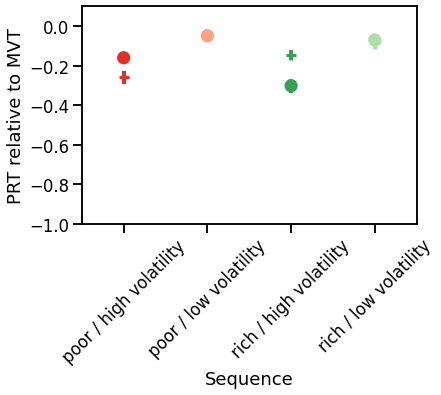

In [120]:
crp_avg = crp_df.groupby(['sub_num','cond_num']).prt_rel_mvt.mean().reset_index()
g=sns.pointplot(x='cond_num',y='prt_rel_mvt',palette=pal,order = [1,2,6,5],data=crp_avg)

bayes_avg = bayes_df.groupby(['sub_num','cond_num']).prt_rel_mvt.mean().reset_index()
sns.pointplot(x='cond_num',y='prt_rel_mvt',palette=pal,markers='+',order = [1,2,6,5],data=bayes_avg)
plt.ylim([-1,0.1])
g.set_xticklabels(['poor / high volatility','poor / low volatility','rich / high volatility','rich / low volatility'])
plt.xticks(rotation=45)
plt.ylabel('PRT relative to MVT')
plt.xlabel('Sequence')
plt.savefig('prm_bayes_crp_comp.png')


In [15]:
crp_sub_avg = crp_df.groupby(['sub_num','cond_num']).prt_rel_mvt.mean().reset_index()
crp_avg=crp_sub_avg.groupby(['cond_num']).prt_rel_mvt.mean().reset_index()
print(crp_avg)
x=crp_avg.prt_rel_mvt.tolist()

   cond_num  prt_rel_mvt
0         1    -0.160416
1         2    -0.049378
2         5    -0.070485
3         6    -0.302118


In [16]:
bayes_sub_avg = bayes_df.groupby(['sub_num','cond_num']).prt_rel_mvt.mean().reset_index()
bayes_avg=bayes_sub_avg.groupby(['cond_num']).prt_rel_mvt.mean().reset_index()
print(bayes_avg)
y=bayes_avg.prt_rel_mvt.tolist()

   cond_num  prt_rel_mvt
0         1    -0.260070
1         2    -0.045791
2         5    -0.088003
3         6    -0.147308


In [18]:
sum([abs(x[i]-y[i]) for i in range(len(x))])

0.2755690483266284

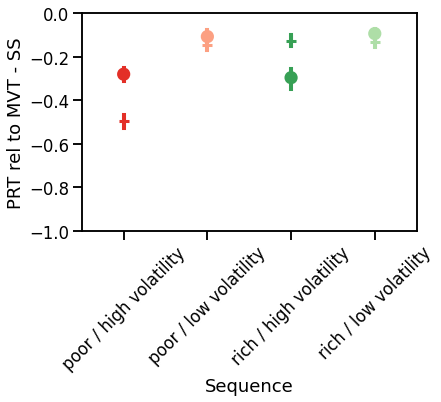

In [122]:
crp_avg = crp_df.groupby(['sub_num','cond_num']).prt_rel_mvt_om.mean().reset_index()
g=sns.pointplot(x='cond_num',y='prt_rel_mvt_om',palette=pal,order = [1,2,6,5],data=crp_avg)
plt.ylim([-1,0])

bayes_avg = bayes_df.groupby(['sub_num','cond_num']).prt_rel_mvt_om.mean().reset_index()
sns.pointplot(x='cond_num',y='prt_rel_mvt_om',palette=pal,markers='+',order = [1,2,6,5],data=bayes_avg)
plt.ylim([-1,0])

g.set_xticklabels(['poor / high volatility','poor / low volatility','rich / high volatility','rich / low volatility'])
plt.xticks(rotation=45)
plt.ylabel('PRT rel to MVT - SS')
plt.xlabel('Sequence')

plt.savefig('prm_steady_state_bayes_crp_comp.png')

In [91]:
crp_avg = crp_df.groupby(['sub_num','cond_num','galaxy']).prt_rel_mvt.mean().reset_index()
bayes_avg = bayes_df.groupby(['sub_num','cond_num','galaxy']).prt_rel_mvt.mean().reset_index()


In [111]:
title_dict = {1:'poor / high volatility',2:'poor / low volatility',6:'rich / high volatility',5:'rich / low volatility'}

In [124]:
crp_avg = crp_df.groupby(['sub_num','cond_num','galaxy']).prt_rel_mvt.mean().reset_index()
bayes_avg = bayes_df.groupby(['sub_num','cond_num','galaxy']).prt_rel_mvt.mean().reset_index()
crp_avg['model'] = 'crp'
bayes_avg['model'] = 'bayes'
all_avg= pd.concat([crp_avg,bayes_avg])

g=sns.catplot(x='galaxy',y='prt_rel_mvt',col='cond_num',palette=['r','k'],col_order=[1,2,6,5],hue='model',kind='point',data=all_avg)
g.set_ylabels('PRT relative to MVT')
g.set_xticklabels(['poor','neutral','rich'])
g.axes[0][0].set_title('poor_extreme')
g.axes[0][1].set_title('poor_graded')
g.axes[0][2].set_title('rich_extreme')
g.axes[0][3].set_title('rich_graded')
plt.ylim([-0.6,0.2])
plt.savefig('prm_bayes_crp_comp_sep_galaxy.png')

KeyError: 'block'

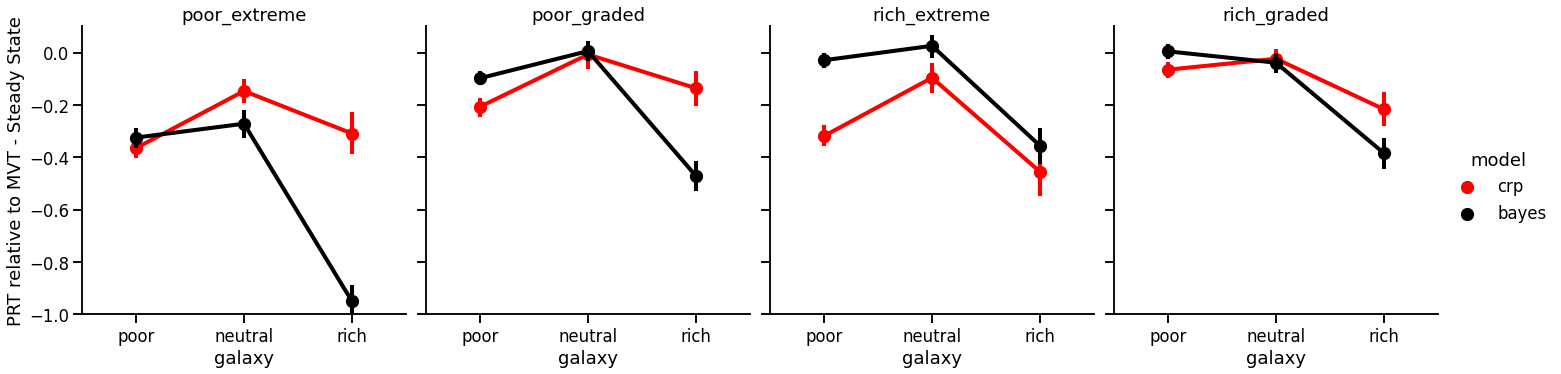

In [115]:
crp_avg = crp_df.groupby(['sub_num','cond_num','galaxy']).prt_rel_mvt_om.mean().reset_index()
bayes_avg = bayes_df.groupby(['sub_num','cond_num','galaxy']).prt_rel_mvt_om.mean().reset_index()
crp_avg['model'] = 'crp'
bayes_avg['model'] = 'bayes'
all_avg= pd.concat([crp_avg,bayes_avg])

g=sns.catplot(x='galaxy',y='prt_rel_mvt_om',col='cond_num',palette=['r','k'],col_order=[1,2,6,5],hue='model',kind='point',data=all_avg)
g.set_ylabels('PRT relative to MVT - Steady State')
g.set_xticklabels(['poor','neutral','rich'])
g.axes[0][0].set_title('poor_extreme')
g.axes[0][1].set_title('poor_graded')
g.axes[0][2].set_title('rich_extreme')
g.axes[0][3].set_title('rich_graded')
plt.ylim([-1,0.1])
plt.savefig('prm_steady_state_bayes_crp_comp_sep_galaxy.png')

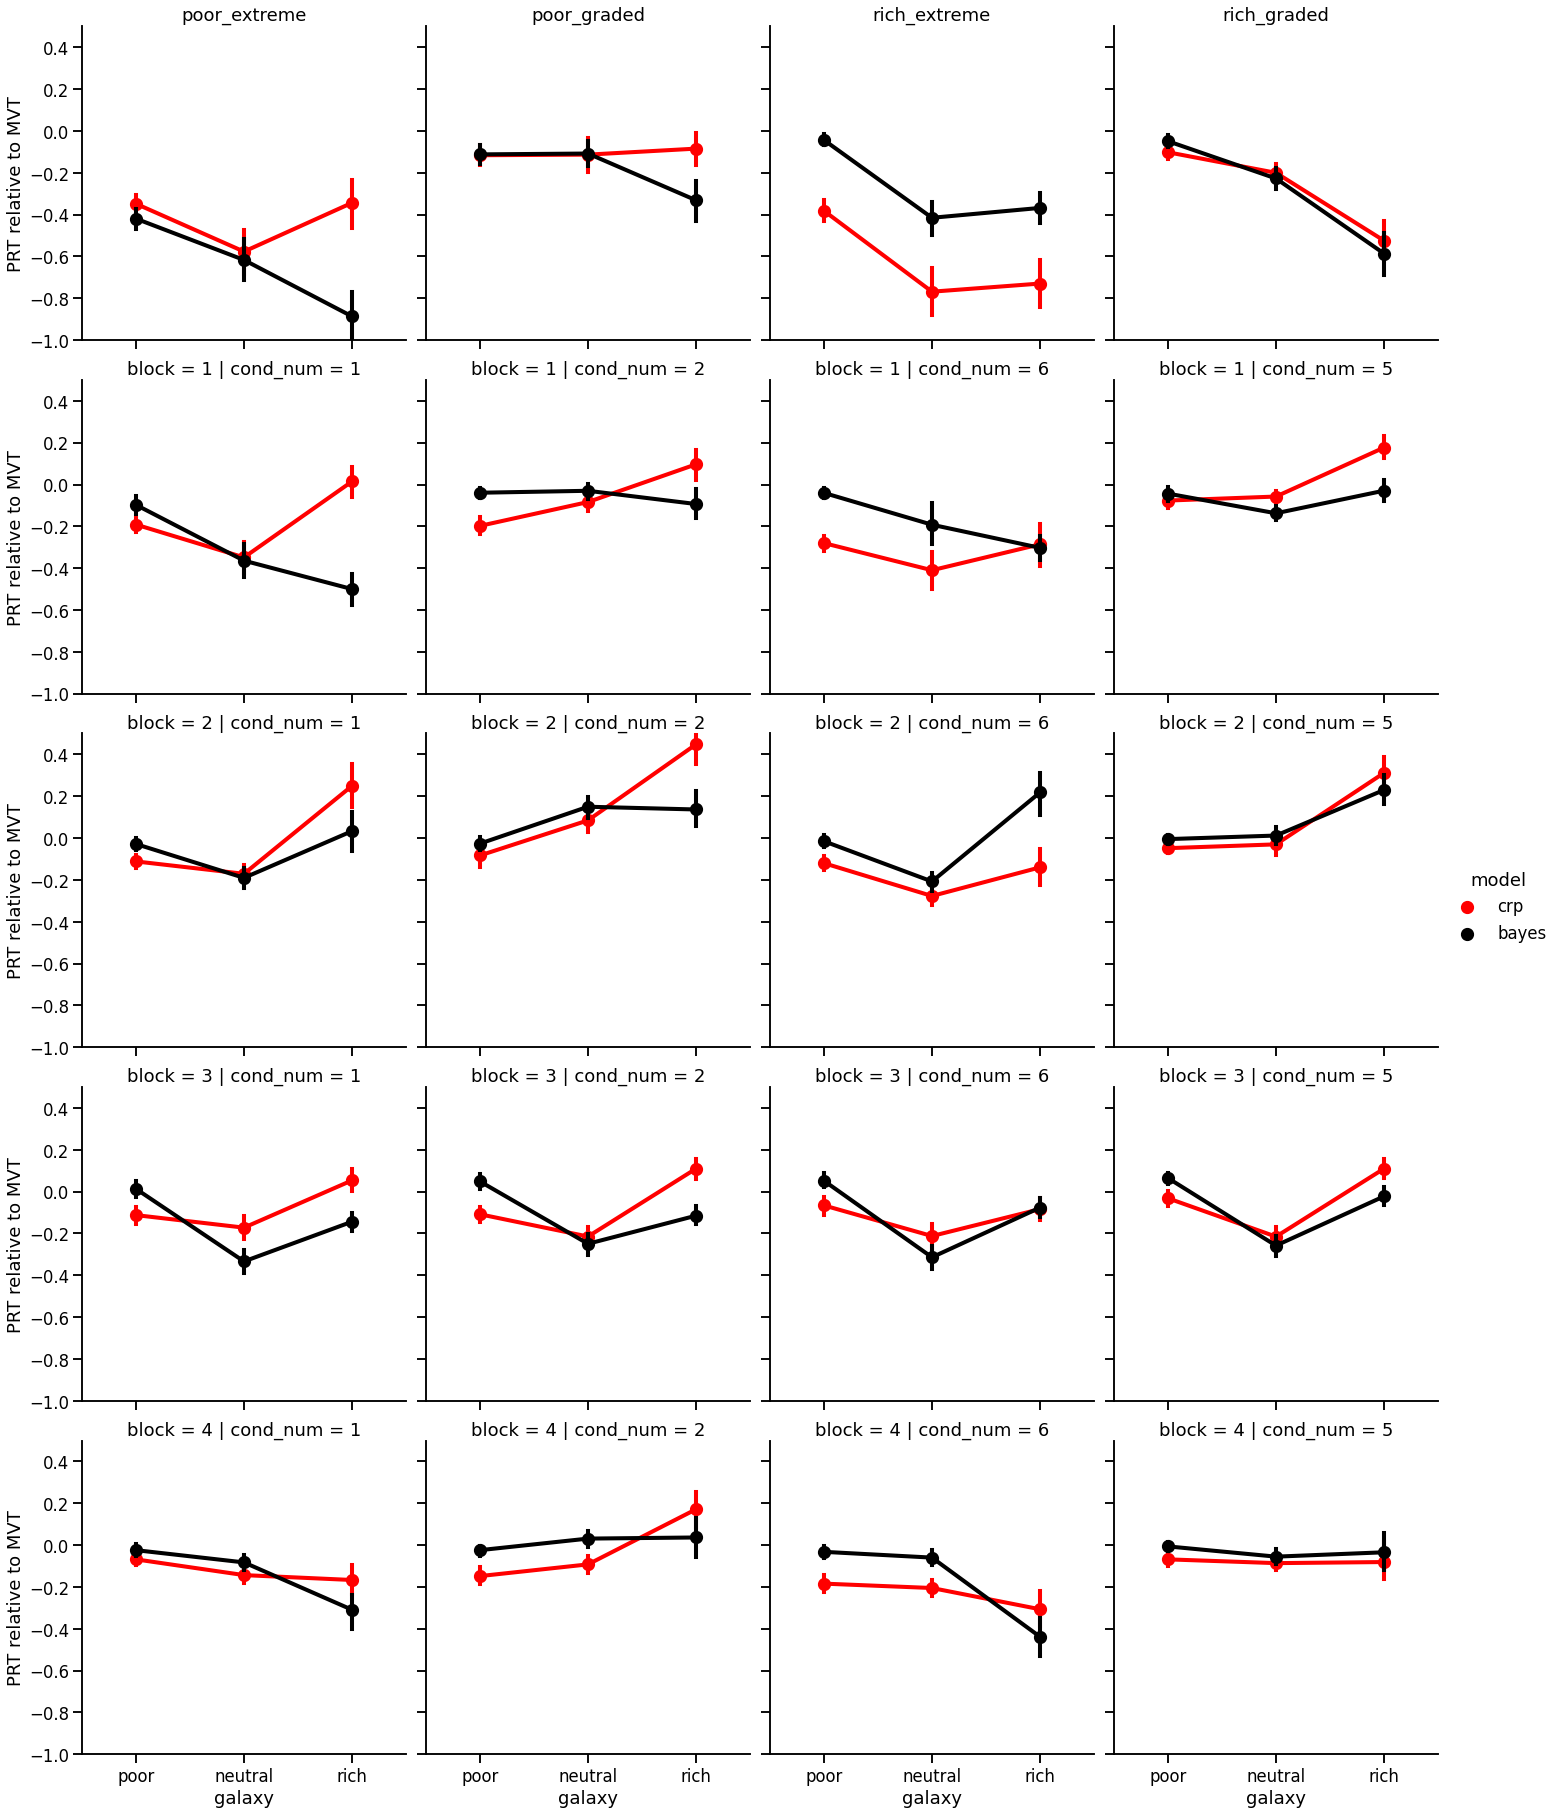

In [128]:
crp_avg = crp_df.groupby(['sub_num','cond_num','galaxy','block']).prt_rel_mvt.mean().reset_index()
bayes_avg = bayes_df.groupby(['sub_num','cond_num','galaxy','block']).prt_rel_mvt.mean().reset_index()
crp_avg['model'] = 'crp'
bayes_avg['model'] = 'bayes'
all_avg= pd.concat([crp_avg,bayes_avg])

g=sns.catplot(x='galaxy',y='prt_rel_mvt',col='cond_num',row='block',palette=['r','k'],col_order=[1,2,6,5],hue='model',kind='point',data=all_avg)
g.set_ylabels('PRT relative to MVT')
g.set_xticklabels(['poor','neutral','rich'])
g.axes[0][0].set_title('poor_extreme')
g.axes[0][1].set_title('poor_graded')
g.axes[0][2].set_title('rich_extreme')
g.axes[0][3].set_title('rich_graded')
plt.ylim([-1,0.5])
plt.savefig('prm_bayes_crp_comp_sep_galaxy_block.png')

In [69]:
with open('../pickled_exp_parms/crp_and_bayes_sims.pkl', 'wb') as f_out:
    pickle.dump([crp_df,bayes_df],f_out)

In [5]:
file = open('../pickled_exp_parms/crp_and_bayes_sims.pkl','rb')
data= pickle.load(file)
crp_df = data[0]
bayes_df = data[1]
file.close()

# big sweep 

In [3]:
def load_pkl(file_name):
    file = open(file_name,'rb')
    data= pickle.load(file)
    diff = data[0]
    file.close()
    return diff

def make_df(files):
    df=pd.DataFrame(columns=['seed','diff'])
    for f in files:
        diff = load_pkl(f)
        seed = f.split("/")[-1].split("_")[-1].split(".")[0]
        tmp = pd.DataFrame({'seed':seed,'diff':diff},index=[0])
        
        df = pd.concat([df,tmp],ignore_index=True)
    return df

In [2]:
import glob
files = glob.glob("../pickled_exp_parms/mdp_eval/*pkl")
df = make_df(files)

NameError: name 'make_df' is not defined

In [12]:
df.sort_values(by='diff', ascending=False)[:10]

,seed,diff
7,243400772,1.408562
3,563341147,0.669951
0,7020760,0.616887
4,65023032,0.551131
2,714037102,0.549834
8,244032615,0.485726
12,213713132,0.474884
9,776541651,0.413490
1,545050533,0.387363
10,771066130,0.334618


In [205]:
file = open('../pickled_exp_parms/blocks/80_10_10/110017437.pkl','rb')
data= pickle.load(file)
exp_struc = data[0]
all_r_0 = data[1]
all_decay = data[2]
file.close()
exp_struc

[[[0, 0], [1, 1, 1], [2, 2, 2], [0, 0, 0, 0, 0], [2, 2], [1], [2, 2, 2, 2]],
 [[0, 0, 0], [2, 2, 2, 2, 2], [1], [2, 2], [0, 0, 0, 0], [2, 2, 2, 2, 2]],
 [[1], [2], [1, 1, 1, 1], [2, 2], [1, 1], [2, 2, 2, 2], [1, 1], [2, 2, 2, 2]],
 [[0, 0, 0], [2, 2, 2, 2, 2, 2], [0, 0], [2, 2, 2, 2, 2, 2, 2, 2, 2]],
 [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [2, 2, 2], [1, 1]]]

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your c

<AxesSubplot:ylabel='Density'>

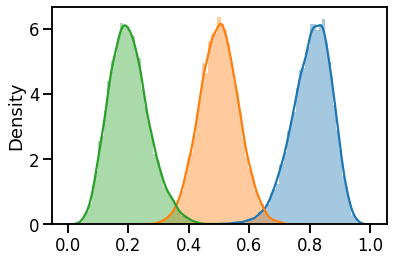

In [392]:
sns.distplot(stats.beta.rvs(a=29,b=7,size=10000))
sns.distplot(stats.beta.rvs(a=29,b=29,size=10000))
sns.distplot(stats.beta.rvs(a=7.4,b=29,size=10000))

In [168]:
x=stats.beta.rvs(a=50,b=12,size=1000)
print(np.mean(x))
stats.tstd(x)

0.807572749881452


0.05196813396645583

In [196]:
y=stats.beta.rvs(a=50,b=50,size=1000)
print(np.mean(y))
stats.tstd(y)

0.5007319201550023


0.05047431204511195

In [185]:
z=stats.beta.rvs(a=13,b=51,size=1000)
print(np.mean(z))
stats.tstd(z)

0.2040143735799249


0.05084345023958491

In [198]:
stats.tstd(np.concatenate([x,y,z]))

0.25169250566249346

In [7]:
file = open('../pickled_exp_parms/blocks/110017437_1.pkl','rb')
data= pickle.load(file)
exp_struc_x = data[0]
all_r_0 = data[1]
all_decay = data[2]
file.close()
x=[sim.flatten_list(all_decay)[i][1] for i in range(100)]
len(all_decay)

5

In [28]:
file = open('../pickled_exp_parms/blocks/110017437_2.pkl','rb')
data= pickle.load(file)
exp_struc_y = data[0]
all_r_0 = data[1]
all_decay = data[2]
file.close()
y=[sim.flatten_list(all_decay)[i][1] for i in range(100)]

In [29]:
[[x[i],y[i],sim.flatten_list(sim.flatten_list(exp_struc_x))[i],sim.flatten_list(sim.flatten_list(exp_struc_y))[i]] for i in range(100)]

[[0.23531220698281663, 0.1211087051820704, 0, 0],
 [0.18998319890383275, 0.3166876818624705, 0, 0],
 [0.4916655786133078, 0.47454291416024147, 1, 1],
 [0.520089926933986, 0.580306747590347, 1, 1],
 [0.44891728768919903, 0.4588671582254627, 1, 1],
 [0.783538372455857, 0.7588539909241215, 2, 2],
 [0.8427050375508086, 0.6823513388500747, 2, 2],
 [0.8009361213876462, 0.8139821301655901, 2, 2],
 [0.1937883188580063, 0.15915969496801882, 0, 0],
 [0.12896361325873512, 0.17928143991658468, 0, 0],
 [0.2163562065278302, 0.16395738642445257, 0, 0],
 [0.14494895440176037, 0.2078689791331258, 0, 0],
 [0.17882105853501282, 0.11703898428288344, 0, 0],
 [0.776778757807718, 0.87161114503454, 2, 2],
 [0.7523314487858063, 0.9008614528649155, 2, 2],
 [0.5663851703999222, 0.5072030529047681, 1, 1],
 [0.8651737163583637, 0.8459675561103994, 2, 2],
 [0.7974154212775798, 0.7661760522446202, 2, 2],
 [0.8733048953937431, 0.814795199272823, 2, 2],
 [0.8156319747093421, 0.8031808468703898, 2, 2],
 [0.150089135395

In [30]:
flat_exp_struc = sim.flatten_list(sim.flatten_list(exp_struc))
flat_decay = sim.flatten_list(all_decay)
poor_gal=np.where(np.array(flat_exp_struc)==0)[0]
neutral_gal=np.where(np.array(flat_exp_struc)==1)[0]
rich_gal=np.where(np.array(flat_exp_struc)==2)[0]
flat_exp_struc

[0,
 0,
 1,
 1,
 1,
 2,
 2,
 2,
 0,
 0,
 0,
 0,
 0,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 0,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 1,
 1,
 1,
 1,
 2,
 2,
 1,
 1,
 2,
 2,
 2,
 2,
 1,
 1,
 2,
 2,
 2,
 2,
 0,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 0,
 0,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 1,
 1]

In [208]:
poor_decay = sim.flatten_list([flat_decay[i] for i in poor_gal])
print(np.mean(poor_decay))
print(stats.tstd(poor_decay))

0.20145246652457152
0.04827072063105613


In [209]:
neutral_decay = sim.flatten_list([flat_decay[i] for i in neutral_gal])
print(np.mean(neutral_decay))
print(stats.tstd(neutral_decay))

0.5004130619327402
0.051288662256396986


In [211]:
rich_decay = sim.flatten_list([flat_decay[i] for i in rich_gal])
print(np.mean(rich_decay))
print(stats.tstd(rich_decay))

0.8077617275895022
0.050716042092518863


In [27]:
df_struc = pd.DataFrame(columns=['condition','block','galaxy','planet','galaxy_type'])

for block in range(5):
    planet_in_block =0
    n_galaxy = len(exp_struc[block])
    print(n_galaxy)
    for galaxy in range(n_galaxy):
        curr_galaxy = exp_struc[block][galaxy] 
        for planet in range(len(curr_galaxy)):
            row = pd.DataFrame({'block':block,'galaxy':galaxy,'planet':planet_in_block,'galaxy_type':curr_galaxy[planet]},index=[0])
            df_struc = pd.concat([df_struc,row],ignore_index=True)
            planet_in_block+= 1

7
6
8
4
3


No handles with labels found to put in legend.


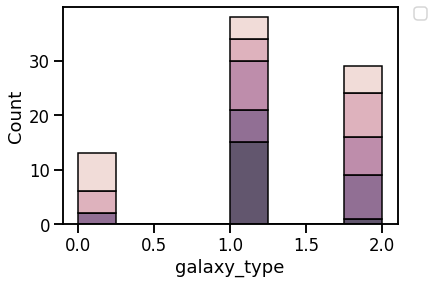

In [28]:
sns.histplot(x='galaxy_type',hue='block',multiple='stack',data=df_struc.query("planet<16"))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

In [2]:
import eval_mdp
crp_df, bayes_df = eval_mdp.run_sims(110017437)


[0.01, 1, 0.9784537767586167, 0.002625411800901244]
[0.01, 1, 0.9904000897010443, 0.0039913972950220275]
[0.01, 1, 0.9871758209412105, 0.001566742559057537]
[0.01, 1, 1, 0.0024353122810322485]
[0.01, 1, 1, 0.0034390957250056585]
[0.01, 1, 0.9930459107711358, 0.002982165167286056]
[0.01, 1, 0.9867487854265321, 0.003760394483350099]
[0.01, 1, 0.9960683141213909, 0.002209509686975118]
[0.01, 1, 0.9843534888111048, 0.004284988440910618]
[0.01, 1, 0.9806602718406522, 0.001256001666387154]
[0.01, 1, 0.9977278818037588, 0.004240597787533096]
[0.01, 1, 0.9948077555921718, 0.00349834896624402]
[0.01, 1, 0.9961583617282384, 0.0034972871394240894]
[0.01, 1, 0.9857857537851247, 0.0038225664910962816]
[0.01, 1, 0.9863842561254706, 0.0038540327910689277]
[0.01, 1, 0.9880594960891468, 0.004354943904563247]
[0.01, 1, 0.996684826204179, 0.0041291144619216725]
[0.01, 1, 0.992732183960279, 0.0026279433000756516]
[0.01, 1, 0.9900262960482001, 0.002685620305830718]
[0.01, 1, 0.9901061539670583, 0.005595726

In [3]:
crp_df['model'] = 'crp'
bayes_df['model'] = 'bayes'
all_df = pd.concat([bayes_df,crp_df])

(-3.5, 1.5)

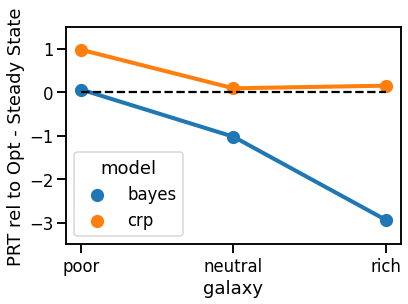

In [4]:
avg = all_df.groupby(by=['sub_num','model','galaxy']).prt_rel_mvt_om.mean().reset_index()

g=sns.pointplot(x='galaxy',y='prt_rel_mvt_om',hue='model',data=avg)
plt.plot([0,2],[0,0],'k--')
g.set_xticklabels(['poor','neutral','rich'])
g.set_ylabel('PRT rel to Opt - Steady State')
g.set_ylim([-3.5,1.5])

In [5]:
len(all_decay)

NameError: name 'all_decay' is not defined

(-3.5, 1.2)

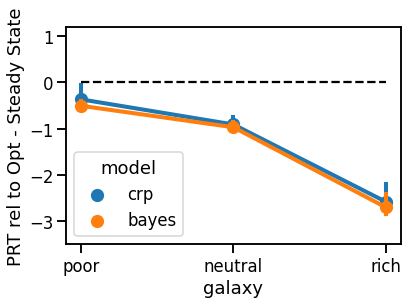

In [5]:
low_r_expec = all_df.query('hyper_mu < 0.3')
avg = low_r_expec.groupby(by=['sub_num','model','galaxy']).prt_rel_mvt_om.mean().reset_index()
g=sns.pointplot(x='galaxy',y='prt_rel_mvt_om',hue='model',data=avg)
plt.plot([0,2],[0,0],'k--')
g.set_xticklabels(['poor','neutral','rich'])
g.set_ylabel('PRT rel to Opt - Steady State')
g.set_ylim([-3.5,1.2])

(-3.5, 1.2)

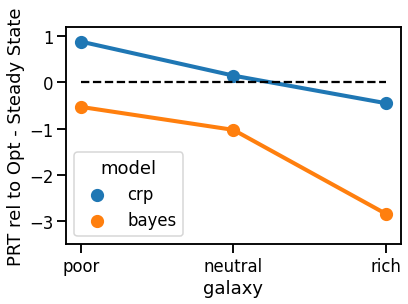

In [6]:
low_r_expec = all_df.query('hyper_mu > 0.8')
avg = low_r_expec.groupby(by=['sub_num','model','galaxy']).prt_rel_mvt_om.mean().reset_index()
g=sns.pointplot(x='galaxy',y='prt_rel_mvt_om',hue='model',data=avg)
plt.plot([0,2],[0,0],'k--')
g.set_xticklabels(['poor','neutral','rich'])
g.set_ylabel('PRT rel to Opt - Steady State')
g.set_ylim([-3.5,1.2])

In [30]:
all_df

,sub_num,hyper_mu,hyper_var,block,galaxy,prt,reward,true_planet,opt_prt,opt_prt_om,prt_rel_mvt,prt_rel_mvt_om,model,alpha,prior_tau
0,0,0.391925,0.045979,0,0,2,"[98.30387881117231, 23.87101134865411]",0,1,1,1,1,bayes,NaN,NaN
1,0,0.391925,0.045979,0,0,1,[106.98080766504562],1,2,1,-1,0,bayes,NaN,NaN
2,0,0.391925,0.045979,0,2,2,"[100.40554558595562, 100.33928800347687]",2,7,4,-5,-2,bayes,NaN,NaN
3,0,0.391925,0.045979,0,2,7,"[99.90894387537197, 90.66128476903586, 77.6043...",3,6,7,1,0,bayes,NaN,NaN
4,0,0.391925,0.045979,0,2,2,"[91.14973484942766, 84.64708929854314]",4,7,3,-5,-1,bayes,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,49,0.609754,0.039011,4,0,2,"[99.50549209272766, 29.410835776891915]",93,2,1,0,1,crp,0.720853,1
14,49,0.609754,0.039011,4,0,2,"[100.52049409304709, 39.70206441847711]",94,2,1,0,1,crp,0.720853,1
15,49,0.609754,0.039011,4,0,1,[103.26352236151153],95,2,1,-1,0,crp,0.720853,1
16,49,0.609754,0.039011,4,0,2,"[108.15759637071248, 30.470424063294566]",96,2,1,0,1,crp,0.720853,1


<AxesSubplot:xlabel='galaxy', ylabel='prt_rel_mvt'>

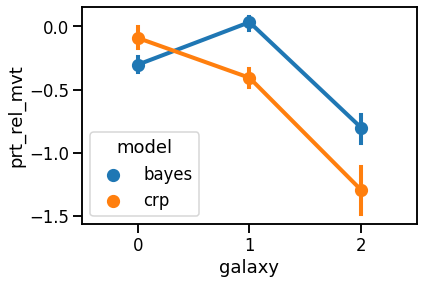

In [41]:
avg = all_df.groupby(by=['sub_num','model','galaxy']).prt_rel_mvt.mean().reset_index()

sns.pointplot(x='galaxy',y='prt_rel_mvt',hue='model',data=avg)

In [4]:
choices, all_reward_exp,true_planet=sim_crp.crp(654025415,[0.01,1,0.9,0.005],100)

[0.01, 1, 0.9, 0.005]
norm_post
[9.99999997e-01 2.00000000e-10 2.00000000e-10 2.00000000e-10
 2.00000000e-10 2.00000000e-10 2.00000000e-10 2.00000000e-10
 2.00000000e-10 2.00000000e-10 2.00000000e-10 2.00000000e-10
 2.00000000e-10 2.00000000e-10 2.00000000e-10]
cluster_mu
[0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9]
norm_post
[0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667 0.06666667
 0.06666667 0.06666667 0.06666667]
cluster_mu
[0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9 0.9]
norm_post
[9.90099027e-03 2.00000000e-10 2.00000000e-10 2.00000000e-10
 2.00000000e-10 2.00000000e-10 2.00000000e-10 2.00000000e-10
 2.00000000e-10 2.00000000e-10 9.90099007e-01 2.00000000e-10
 2.00000000e-10 2.00000000e-10 2.00000000e-10]
cluster_mu
[0.9        0.9        0.9        0.9        0.9        0.9
 0.9        0.9        0.9        0.9        0.14061043 0.9
 0.9        0.9        0.9       ]
norm_po

norm_post
[8.31946753e-01 1.66389371e-03 2.00000000e-10 2.00000000e-10
 2.00000000e-10 2.00000000e-10 2.00000000e-10 2.00000000e-10
 2.00000000e-10 2.00000000e-10 1.66389351e-01 2.00000000e-10
 2.00000000e-10 2.00000000e-10 2.00000000e-10]
cluster_mu
[0.80314637 0.9        0.9        0.9        0.9        0.9
 0.9        0.9        0.9        0.9        0.14061043 0.9
 0.9        0.9        0.9       ]
norm_post
[9.99836392e-01 1.63606511e-04 1.51066317e-10 1.51066317e-10
 1.51066317e-10 1.51066317e-10 1.51066317e-10 1.51066317e-10
 1.51066317e-10 1.51066317e-10 1.41233575e-10 1.51066317e-10
 1.51066317e-10 1.51066317e-10 1.51066317e-10]
cluster_mu
[0.80314637 0.9        0.9        0.9        0.9        0.9
 0.9        0.9        0.9        0.9        0.14061043 0.9
 0.9        0.9        0.9       ]
norm_post
[9.99936421e-01 6.35773057e-05 1.11039293e-10 1.11039293e-10
 1.11039293e-10 1.11039293e-10 1.11039293e-10 1.11039293e-10
 1.11039293e-10 1.11039293e-10 1.07218303e-10 1.11039293

norm_post
[7.85153460e-01 7.13776072e-04 2.00000000e-10 2.00000000e-10
 1.42755175e-01 2.00000000e-10 2.00000000e-10 2.00000000e-10
 2.00000000e-10 2.00000000e-10 7.13775874e-02 2.00000000e-10
 2.00000000e-10 2.00000000e-10 2.00000000e-10]
cluster_mu
[0.80188171 0.9        0.9        0.9        0.87453237 0.9
 0.9        0.50808239 0.9        0.9        0.14061043 0.9
 0.9        0.9        0.9       ]
norm_post
[9.98879749e-01 8.83896636e-07 2.19739006e-07 2.19739006e-07
 1.11549610e-03 2.19739006e-07 2.19739006e-07 1.43819960e-06
 2.19739006e-07 2.19739006e-07 2.35227923e-07 2.19739006e-07
 2.19739006e-07 2.19739006e-07 2.19739006e-07]
cluster_mu
[0.80188171 0.9        0.9        0.9        0.87453237 0.9
 0.9        0.50808239 0.9        0.9        0.14061043 0.9
 0.9        0.9        0.9       ]
norm_post
[0.78311526 0.00605508 0.00605508 0.00605508 0.00605765 0.00605508
 0.00605508 0.13816614 0.00605508 0.00605508 0.00605508 0.00605508
 0.00605508 0.00605508 0.00605508]
cluster_m

norm_post
[3.74843814e-01 8.32986255e-02 4.16493327e-04 2.00000000e-10
 8.32986255e-02 2.00000000e-10 2.00000000e-10 2.00000000e-10
 2.00000000e-10 2.00000000e-10 1.66597251e-01 4.16493129e-02
 2.00000000e-10 1.66597251e-01 8.32986255e-02]
cluster_mu
[0.80188171 0.86348333 0.88788006 0.82828359 0.87453237 0.88850756
 0.89093862 0.50808239 0.9        0.9        0.1416699  0.89101416
 0.9        0.9        0.9       ]
norm_post
[6.83226834e-10 6.82481492e-10 6.82480797e-10 6.82480796e-10
 6.82480815e-10 6.82480796e-10 6.82480796e-10 6.85369741e-10
 6.82480796e-10 6.82480796e-10 9.99999990e-01 6.82480798e-10
 6.82480796e-10 6.82480797e-10 6.82480797e-10]
cluster_mu
[0.80188171 0.86348333 0.88788006 0.82828359 0.87453237 0.88850756
 0.89093862 0.50808239 0.9        0.9        0.1416699  0.89101416
 0.9        0.9        0.9       ]
norm_post
[4.39824069e-01 3.99840263e-04 2.00000000e-10 2.00000000e-10
 3.99840065e-02 7.99680128e-02 3.99840065e-02 3.99840065e-02
 7.99680128e-02 2.00000000e-

norm_post
[3.22476620e-01 9.67429860e-02 3.22476621e-02 3.22476621e-02
 3.22476621e-02 3.22476819e-04 2.00000000e-10 9.67429860e-02
 9.67429860e-02 2.00000000e-10 3.22476621e-02 6.44953241e-02
 9.67429860e-02 9.67429860e-02 2.00000000e-10]
cluster_mu
[0.8013019  0.86348333 0.88788006 0.82828359 0.86817872 0.88850756
 0.89093862 0.50756328 0.9        0.9        0.14208476 0.89101416
 0.89279266 0.9        0.9       ]
norm_post
[4.48624794e-03 5.22834678e-05 2.27475803e-06 1.04630729e-04
 8.50572818e-06 2.05552075e-08 2.99204405e-10 9.95334195e-01
 2.11317693e-06 2.99201248e-10 2.99213903e-10 3.50191244e-06
 4.11218550e-06 2.11317693e-06 2.99201248e-10]
cluster_mu
[0.8013019  0.86348333 0.88788006 0.82828359 0.86817872 0.88850756
 0.89093862 0.50756328 0.9        0.9        0.14208476 0.89101416
 0.89279266 0.9        0.9       ]
norm_post
[8.48523423e-08 1.61867552e-10 1.43994920e-10 4.50642454e-10
 1.44995234e-10 1.43939286e-10 1.43938861e-10 9.99999913e-01
 1.43950350e-10 1.43938861e-

...

norm_post
[4.99891327e-01 2.17344057e-02 4.34688112e-02 2.17344255e-04
 4.34688112e-02 2.00000000e-10 2.00000000e-10 2.00000000e-10
 4.34688112e-02 2.00000000e-10 1.73875244e-01 2.00000000e-10
 2.00000000e-10 1.08672028e-01 6.52032167e-02]
cluster_mu
[0.800943   0.85667637 0.88377597 0.82828359 0.86817872 0.88655953
 0.88623127 0.50756328 0.89603776 0.89511838 0.14208476 0.89101416
 0.88208122 0.9        0.89478155]
norm_post
[7.37513928e-01 2.58622730e-02 3.80345252e-02 3.13890145e-04
 4.65823452e-02 2.10981690e-10 2.11443962e-10 1.27081889e-10
 3.12449109e-02 1.99978527e-10 1.27064791e-10 2.05326985e-10
 2.16707096e-10 7.25385292e-02 4.79095968e-02]
cluster_mu
[0.800943   0.85667637 0.88377597 0.82828359 0.86817872 0.88655953
 0.88623127 0.50756328 0.89603776 0.89511838 0.14208476 0.89101416
 0.88208122 0.9        0.89478155]
norm_post
[8.63025689e-01 2.08423031e-02 2.06660681e-02 3.31727659e-04
 3.23961009e-02 1.49044368e-10 1.49641535e-10 1.05802833e-10
 1.33600592e-02 1.37462939e-

norm_post
[3.59928014e-01 3.99920017e-02 1.99960009e-02 1.99960009e-02
 1.99960009e-02 7.99840032e-02 7.99840032e-02 5.99880024e-02
 1.19976005e-01 1.99960207e-04 1.19976005e-01 1.99960009e-02
 1.99960009e-02 3.99920017e-02 2.00000000e-10]
cluster_mu
[0.80090691 0.85667637 0.88128003 0.82828359 0.86817872 0.88655953
 0.88623127 0.50756328 0.89603776 0.89511838 0.14208476 0.89101416
 0.88208122 0.9        0.89478155]
norm_post
[6.11548571e-01 4.90937319e-02 1.77039795e-02 3.14403223e-02
 2.14675200e-02 6.47139936e-02 6.51914714e-02 2.20565631e-05
 8.13427475e-02 1.37629673e-04 1.30982333e-10 1.49406628e-02
 1.74969365e-02 2.49003769e-02 2.00507158e-10]
cluster_mu
[0.80090691 0.85667637 0.88128003 0.82828359 0.86817872 0.88655953
 0.88623127 0.50756328 0.89603776 0.89511838 0.14208476 0.89101416
 0.88208122 0.9        0.89478155]
norm_post
[8.06010548e-01 3.64098253e-02 8.32446473e-03 3.36892231e-02
 1.29621309e-02 2.69616116e-02 2.74937027e-02 2.64011630e-08
 2.69769973e-02 4.63961828e-

norm_post
[4.81392334e-01 1.85150899e-02 5.55452694e-02 1.85151097e-04
 2.00000000e-10 1.85150899e-02 2.00000000e-10 2.00000000e-10
 9.25754489e-02 2.00000000e-10 1.29605628e-01 1.85150899e-02
 2.00000000e-10 1.11090539e-01 7.40603592e-02]
cluster_mu
[0.80086385 0.85667637 0.88128003 0.82828359 0.86817872 0.88655953
 0.88623127 0.50756328 0.89603776 0.89511838 0.14208476 0.89101416
 0.88208122 0.9        0.89478155]
norm_post
[8.20418732e-01 1.73992320e-02 3.27533555e-02 2.53732634e-04
 2.09636478e-10 9.64973015e-03 1.86356419e-10 1.33749369e-10
 3.82500857e-02 1.75578241e-10 1.33577044e-10 8.69419632e-03
 1.91796576e-10 4.09489901e-02 3.16319450e-02]
cluster_mu
[0.80086385 0.85667637 0.88128003 0.82828359 0.86817872 0.88655953
 0.88623127 0.50756328 0.89603776 0.89511838 0.14208476 0.89101416
 0.88208122 0.9        0.89478155]
norm_post
[8.69317294e-01 1.71957150e-02 2.64761994e-02 2.83036474e-04
 1.77049940e-10 7.34345589e-03 1.47087607e-10 1.06791050e-10
 2.56572481e-02 1.35334865e-

norm_post
[5.16580569e-01 1.66639093e-04 3.33277788e-02 3.33277788e-02
 1.66638895e-02 2.00000000e-10 2.00000000e-10 2.00000000e-10
 4.99916681e-02 2.00000000e-10 1.33311115e-01 2.00000000e-10
 3.33277788e-02 1.33311115e-01 4.99916681e-02]
cluster_mu
[0.80072762 0.85667637 0.88128003 0.82828359 0.86817872 0.88424663
 0.88623127 0.50756328 0.89603776 0.89373203 0.14208476 0.89101416
 0.88208122 0.9        0.89478155]
norm_post
[9.88184335e-01 1.30091023e-05 2.85958920e-04 1.05291126e-02
 3.18836315e-04 1.50863534e-07 1.50863475e-07 9.99897400e-07
 1.00239621e-04 1.50863144e-07 1.59472476e-07 1.50863258e-07
 2.93189476e-04 1.58729282e-04 1.14826720e-04]
cluster_mu
[0.80072762 0.85667637 0.88128003 0.82828359 0.86817872 0.88424663
 0.88623127 0.50756328 0.89603776 0.89373203 0.14208476 0.89101416
 0.88208122 0.9        0.89478155]
norm_post
[9.97214820e-01 6.86972360e-06 9.41296591e-06 2.55009585e-03
 1.36714910e-05 5.95995667e-06 5.95995667e-06 1.46684286e-04
 6.33052885e-06 5.95995667e-

norm_post
[5.52156393e-01 1.49231460e-02 4.47694375e-02 1.49231460e-02
 1.49231658e-04 1.49231460e-02 2.00000000e-10 2.00000000e-10
 5.96925832e-02 2.00000000e-10 1.19385166e-01 1.49231460e-02
 2.00000000e-10 1.04462020e-01 5.96925832e-02]
cluster_mu
[0.80066267 0.85667637 0.88128003 0.82828359 0.86817872 0.88424663
 0.88424447 0.50756328 0.8952962  0.89102427 0.14208476 0.89101416
 0.87924142 0.9        0.89297077]
norm_post
[9.93760047e-01 1.05288630e-03 3.48333469e-04 4.32349287e-03
 2.74113448e-06 8.26062589e-05 1.48004027e-07 9.79969129e-07
 1.18704416e-04 1.48003654e-07 1.56833400e-07 4.50940217e-05
 1.48004430e-07 1.12041196e-04 1.52472390e-04]
cluster_mu
[0.80066267 0.85667637 0.88128003 0.82828359 0.86817872 0.88424663
 0.88424447 0.50756328 0.8952962  0.89102427 0.14208476 0.89101416
 0.87924142 0.9        0.89297077]
norm_post
[9.93354554e-01 1.70467295e-04 1.31143648e-04 8.20008328e-04
 1.29693401e-04 1.29916602e-04 1.29668811e-04 4.22638932e-03
 1.29796403e-04 1.29668811e-

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your c

<AxesSubplot:ylabel='Density'>

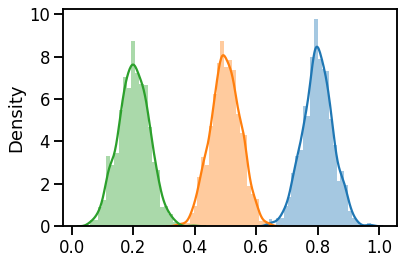

In [49]:
sns.distplot(stats.norm.rvs(loc=0.8,scale=0.05,size=1000))
sns.distplot(stats.norm.rvs(loc=0.5,scale=0.05,size=1000))
sns.distplot(stats.norm.rvs(loc=0.2,scale=0.05,size=1000))

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

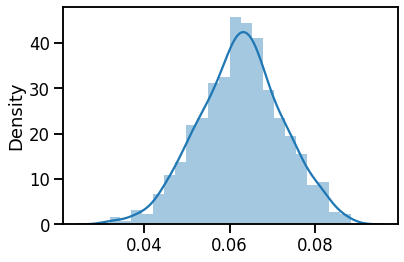

In [78]:
sns.distplot(np.clip(stats.norm.rvs(loc=0.0625,scale=0.01,size=1000),0.01,1))

In [18]:
all_reward_exp

[[98.97646170257643, 33.01122669775992],
 [101.88992055468688,
  86.32398775962884,
  79.69344187252922,
  79.25368987526035,
  71.71597986756149,
  65.78271516617873,
  59.149823466833695],
 [99.42535897708579,
  99.42535897708579,
  89.6889030810022,
  85.7127895983655,
  77.85015679126045,
  65.98601022320436,
  62.089396538037256,
  56.54402862317872],
 [98.49324860059811,
  92.08285533564609,
  77.5632884613873,
  76.97687967215141,
  72.01629979851246,
  61.52059837304994],
 [106.04904993041139,
  104.87208907059589,
  87.2319252865594,
  74.63304903485617,
  65.10247937571384],
 [95.52593434750459, 74.32829230977819, 61.42059702512444],
 [93.52862988145118, 78.38048972774108, 69.51371588729937, 60.160701026392104],
 [110.46425939095886, 65.21942147336381],
 [106.20786394535902, 62.559281712811725],
 [94.47811827634541, 79.08641760711753, 63.61203181322436],
 [103.29169631766158,
  81.54232730677296,
  76.00066331343652,
  67.42560222451388,
  57.44770048590912],
 [97.49696575185

In [19]:
prts =  [sim_crp.get_prts(block) for block in choices]
prts

[[2, 7, 8, 6, 5, 3, 4, 2, 2, 3, 5, 2, 2, 2],
 [2, 2, 2, 2, 2, 2, 9, 9, 13, 7, 4, 5],
 [1, 2, 1, 2, 2, 2, 7, 2, 2, 2, 3, 2, 2, 3, 2, 2, 2, 2, 1],
 [2, 2, 7, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 9, 2],
 [2, 2, 2, 2, 2, 2, 11, 8, 2, 2, 2, 2, 2, 2, 2, 2]]

In [20]:
[list(range(len(prts[i]))) for i in range(5)]

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]]

In [21]:
opt_prt,__,__,__,__ = sim.get_indiv_sub_prt(12345,true_planet,all_reward_exp)


planet: 0
reward: 98.97646170257643
estim_decay: 0.5
overall_rr: 14.13949452893949
actual decay: 0.3335260336640284
r :0
true planet: 0
stored decay: 0.3335260336640284
reward: 33.01122669775992
estim_decay: 0.4167630168320142
overall_rr: 12.570256038127273
planet: 1
reward: 101.88992055468688
estim_decay: 0.4167630168320142
overall_rr: 10.394560398001033
actual decay: 0.8472279425647072
r :1
true planet: 1
stored decay: 0.8472279425647072
reward: 86.32398775962884
estim_decay: 0.5602513254095786
overall_rr: 12.315446027486617
actual decay: 0.9231899955136164
r :1
true planet: 1
stored decay: 0.9231899955136164
reward: 79.69344187252922
estim_decay: 0.650985992935588
overall_rr: 13.55576401990445
actual decay: 0.994481955014915
r :1
true planet: 1
stored decay: 0.994481955014915
reward: 79.25368987526035
estim_decay: 0.7196851853514534
overall_rr: 14.519658438255806
actual decay: 0.9048913682181526
r :1
true planet: 1
stored decay: 0.9048913682181526
reward: 71.71597986756149
estim_dec

In [8]:
all_decay

NameError: name 'exp_struc' is not defined

In [5]:
prts =  [sim_crp.get_prts(block) for block in choices]
exp_struc, __,__ = sim_crp.load_data(370554332)
sub_df = pd.DataFrame(columns=['sub_num','hyper_mu','hyper_var','block','galaxy','prt'])
for block in range(5):
    n_planets = len(prts[block])
    tmp = pd.DataFrame({'sub_num':[1]*n_planets,
                        'hyper_mu':[0.5]*n_planets,'hyper_var':[0.1]*n_planets,
                        'block':[block]*n_planets,'galaxy':sim.flatten_list(exp_struc[block])[:n_planets],
                        'prt':prts[block]})
    sub_df = pd.concat([sub_df,tmp])
sub_df['reward'] = all_reward_exp
sub_df['true_planet'] = true_planet
sub_df['opt_prt'],__,__,__,__ = sim.get_indiv_sub_prt(370554332,true_planet,all_reward_exp)
sub_df['opt_prt_om'],__,__,__,__ = sim.get_indiv_sub_prt_omniscent(370554332,true_planet,all_reward_exp)

planet: 0
reward: 105.4927242350651
estim_decay: 0.5
overall_rr: 15.070389176437871
actual decay: 0.8673406702668454


TypeError: 'float' object is not subscriptable

In [15]:
sub_df['prt_rel_mvt'] =sub_df['prt']-sub_df['opt_prt']
sub_df['prt_rel_om'] =sub_df['prt']-sub_df['opt_prt_om']

np.mean(sub_df['prt_rel_om'])

0.11904761904761904

In [16]:
sub_df = sub_df.astype({'opt_prt_om':'int','galaxy':'int','prt_rel_om':'int'})
sub_df.groupby(by=['galaxy']).prt_rel_om.mean()

galaxy
0    0.666667
1    0.485714
2   -0.405405
Name: prt_rel_om, dtype: float64

In [65]:
sub_df


,sub_num,hyper_mu,hyper_var,block,galaxy,prt,reward,true_planet,opt_prt,opt_prt_om,prt_rel_mvt,prt_rel_om
0,1,0.5,0.1,0,1,2,"[95.64232220878739, 54.44552213872577]",0,1,2,1,0
1,1,0.5,0.1,0,1,2,"[102.56980255238291, 61.26563807603617]",1,2,2,0,0
2,1,0.5,0.1,0,1,2,"[96.77069602637746, 56.21329640956087]",2,2,2,0,0
3,1,0.5,0.1,0,2,3,"[106.15360176613582, 104.9484284296837, 86.218...",3,6,4,-3,-1
4,1,0.5,0.1,0,2,5,"[98.4132831740702, 93.82576780919604, 78.94973...",4,5,6,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...
15,1,0.5,0.1,4,1,2,"[95.52233665054568, 61.78524489971593]",95,3,2,-1,0
16,1,0.5,0.1,4,1,2,"[104.5689068424713, 65.93725978598711]",96,3,2,-1,0
17,1,0.5,0.1,4,1,2,"[95.65710200970261, 48.27174858422439]",97,2,2,0,0
18,1,0.5,0.1,4,2,4,"[96.90768376519, 94.3952930622561, 94.39529306...",98,5,5,-1,-1


In [9]:
exp_struc, rho_0, all_decay = sim.load_data(710013605)
exp_struc

[[[2, 2], [0, 0], [1, 1, 1, 1, 1, 1, 1], [0, 0, 0, 0], [2, 2, 2], [0, 0, 0]],
 [[0, 0, 0, 0, 0, 0],
  [1, 1],
  [0],
  [1, 1, 1],
  [0, 0, 0, 0],
  [1, 1],
  [0, 0],
  [1]],
 [[0],
  [1, 1, 1, 1, 1, 1],
  [2, 2, 2],
  [1],
  [0],
  [1, 1, 1, 1],
  [0, 0],
  [1, 1, 1]],
 [[1, 1, 1, 1, 1, 1, 1, 1], [0, 0], [1, 1, 1], [0, 0, 0, 0, 0, 0], [2, 2]],
 [[0], [1, 1, 1, 1, 1, 1, 1, 1], [2, 2], [1, 1, 1], [0, 0], [1, 1, 1, 1], [0]]]

In [51]:
all_decay[0][1]

[0.5973067759855295,
 0.5907559904721235,
 0.6614907825051433,
 0.5340798171563298,
 0.7253946092605589,
 0.5679384562292584,
 0.6556582728514464,
 0.6772303986002188,
 0.5625833785716271,
 0.6311978460165701,
 0.6225363094526513,
 0.6157525091078733,
 0.6113805931992806,
 0.5752020309188224,
 0.48389517436787716,
 0.6191198549559134,
 0.49124365768467293,
 0.4696019548920195,
 0.5137197296839123,
 0.5272578148049917,
 0.5282412211882482,
 0.4616050627490754,
 0.4977018760823933,
 0.671059978525742,
 0.6287760971304451,
 0.6206086902188228,
 0.7096626148375519,
 0.6353529572132115,
 0.691017502478322,
 0.5591365286510108,
 0.6291647729706197,
 0.5655582334878082,
 0.530106141883125,
 0.5858413246470282,
 0.5389685304424578,
 0.543480105606101,
 0.6161046820848846,
 0.6108814563479789,
 0.7380573575302833,
 0.5626505767045016,
 0.593695529912546,
 0.5880628394345382,
 0.5784965189691198,
 0.5883363010793496,
 0.568552033540645]

In [52]:
opt_prt,__,__,__,__ = sim.get_indiv_sub_prt(370554332,true_planet,all_reward_exp)
opt_prt


planet: 0
reward: 95.64232220878739
estim_decay: 0.5
overall_rr: 13.663188886969627
actual decay: 0.5692618171678338
stored decay: 0.5692618171678338
reward: 54.44552213872577
estim_decay: 0.5346309085839169
overall_rr: 14.294080414048873
planet: 1
reward: 102.56980255238291
estim_decay: 0.5346309085839169
overall_rr: 11.229228751106492
actual decay: 0.5973067759855295
stored decay: 0.5973067759855295
reward: 61.26563807603617
estim_decay: 0.5555228643844544
overall_rr: 12.073972499074317
planet: 2
reward: 96.77069602637746
estim_decay: 0.5555228643844544
overall_rr: 10.807736342166043
actual decay: 0.5808917236085438
stored decay: 0.5808917236085438
reward: 56.21329640956087
estim_decay: 0.5618650791904768
overall_rr: 11.250777768960736
planet: 3
reward: 106.15360176613582
estim_decay: 0.5618650791904768
overall_rr: 10.711418302392643
actual decay: 0.9886468917078555
stored decay: 0.9886468917078556
reward: 104.9484284296837
estim_decay: 0.6472214416939526
overall_rr: 11.8949001334682

[1,
 2,
 2,
 6,
 5,
 2,
 3,
 4,
 7,
 6,
 6,
 5,
 6,
 6,
 9,
 5,
 7,
 7,
 2,
 2,
 3,
 3,
 2,
 2,
 2,
 2,
 2,
 5,
 9,
 9,
 2,
 3,
 2,
 2,
 4,
 6,
 3,
 6,
 3,
 5,
 5,
 6,
 4,
 8,
 6,
 6,
 6,
 7,
 8,
 4,
 7,
 3,
 6,
 7,
 2,
 4,
 3,
 5,
 7,
 6,
 5,
 7,
 5,
 6,
 5,
 4,
 6,
 3,
 3,
 2,
 2,
 3,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 2,
 5,
 3]

In [30]:
opt_prt_om,__,__,__,__ = sim.get_indiv_sub_prt_omniscent(370554332,true_planet,all_reward_exp)
opt_prt_om

[1,
 3,
 1,
 4,
 3,
 3,
 4,
 2,
 3,
 4,
 3,
 4,
 3,
 4,
 2,
 3,
 2,
 2,
 4,
 2,
 1,
 2,
 1,
 3,
 2,
 3,
 4,
 2,
 1,
 1,
 1,
 3,
 3,
 2,
 1,
 7,
 4,
 3,
 2,
 1,
 1,
 1,
 2,
 2,
 5,
 1,
 3,
 3,
 2,
 4,
 3,
 2,
 1,
 1,
 5,
 5,
 3,
 1,
 2,
 2,
 5,
 3,
 5,
 6,
 2,
 3,
 3,
 1,
 2,
 2,
 3,
 2,
 2,
 3,
 2,
 1,
 1,
 3,
 1,
 1,
 3,
 2,
 4,
 2,
 3,
 1,
 4,
 3,
 5,
 5,
 4,
 2]

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. P

<AxesSubplot:ylabel='Density'>

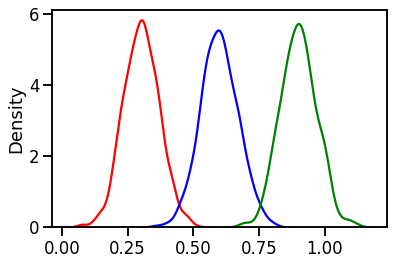

In [39]:
sns.distplot(stats.norm.rvs(loc=0.3,scale=0.07,size=1000),color='r',hist=False)
sns.distplot(stats.norm.rvs(loc=0.6,scale=0.07,size=1000),color='b',hist=False)
sns.distplot(stats.norm.rvs(loc=0.9,scale=0.07,size=1000),color='g',hist=False)

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).
  warnings.warn(msg, FutureWarning)
/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. P

<AxesSubplot:ylabel='Density'>

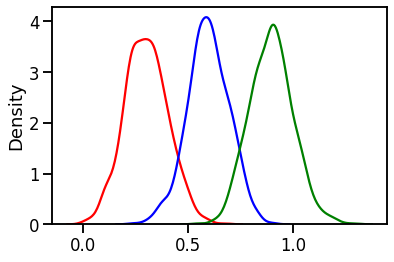

In [43]:
sns.distplot(stats.norm.rvs(loc=0.3,scale=0.1,size=1000),color='r',hist=False)
sns.distplot(stats.norm.rvs(loc=0.6,scale=0.1,size=1000),color='b',hist=False)
sns.distplot(stats.norm.rvs(loc=0.9,scale=0.1,size=1000),color='g',hist=False)

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

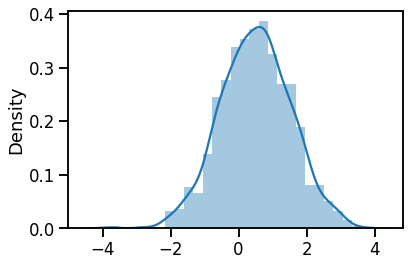

In [54]:
sns.distplot(stats.norm.rvs(loc=0.5,scale=1,size=1000))


In [13]:
crp_df['model'] ='crp'
bayes_df['model'] ='bayes'
all_sim = pd.concat([bayes_df,crp_df])


Text(0.5, 0, 'Model')

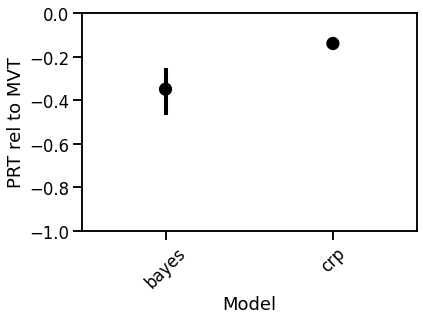

In [25]:
all_sim_avg = all_sim.groupby(['sub_num','model']).prt_rel_mvt.mean().reset_index()
g=sns.pointplot(x='model',y='prt_rel_mvt',ci=68,color='k',join=False,data=all_sim_avg)
plt.ylim([-1,0])


plt.xticks(rotation=45)
plt.ylabel('PRT rel to MVT')
plt.xlabel('Model')

Text(0.5, 0, 'Model')

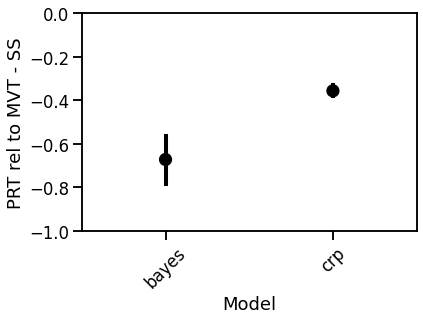

In [26]:
all_sim_avg = all_sim.groupby(['sub_num','model']).prt_rel_mvt_om.mean().reset_index()
g=sns.pointplot(x='model',y='prt_rel_mvt_om',ci=68,color='k',join=False,data=all_sim_avg)
plt.ylim([-1,0])


plt.xticks(rotation=45)
plt.ylabel('PRT rel to MVT - SS')
plt.xlabel('Model')

Text(0.5, 0, 'Galaxy')

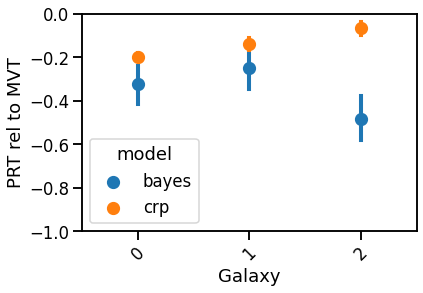

In [23]:
all_sim_avg = all_sim.groupby(['sub_num','model','galaxy']).prt_rel_mvt.mean().reset_index()
g=sns.pointplot(x='galaxy',y='prt_rel_mvt',hue='model',ci=68,join=False,data=all_sim_avg)
plt.ylim([-1,0])


plt.xticks(rotation=45)
plt.ylabel('PRT rel to MVT')
plt.xlabel('Galaxy')

Text(0.5, 0, 'Galaxy')

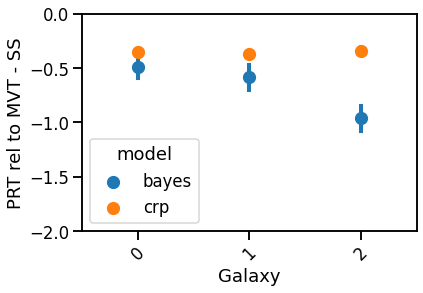

In [24]:
all_sim_avg = all_sim.groupby(['sub_num','model','galaxy']).prt_rel_mvt_om.mean().reset_index()
g=sns.pointplot(x='galaxy',y='prt_rel_mvt_om',hue='model',ci=68,join=False,data=all_sim_avg)
plt.ylim([-2,0])


plt.xticks(rotation=45)
plt.ylabel('PRT rel to MVT - SS')
plt.xlabel('Galaxy')

In [14]:
file = open('../pickled_exp_parms/blocks/563075004.pkl','rb')
data= pickle.load(file)
exp_struc = data[0]
all_r_0 = data[1]
all_decay = data[2]
file.close()

In [15]:
exp_struc

[[[1, 1, 1],
  [2, 2],
  [1, 1],
  [0],
  [2, 2, 2, 2],
  [1],
  [0, 0],
  [2],
  [1],
  [2, 2, 2, 2]],
 [[2, 2, 2, 2, 2],
  [0],
  [1],
  [0, 0, 0, 0, 0],
  [1],
  [2, 2],
  [1],
  [2, 2],
  [1],
  [2, 2]],
 [[1],
  [2, 2, 2],
  [0, 0],
  [1],
  [2],
  [0],
  [1],
  [2],
  [0, 0],
  [1, 1],
  [0, 0, 0, 0],
  [2],
  [0]],
 [[2, 2],
  [1],
  [2, 2, 2, 2],
  [1],
  [0, 0, 0],
  [2],
  [0],
  [2, 2],
  [0],
  [2, 2],
  [1, 1, 1]],
 [[1, 1], [2, 2], [0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1], [2, 2, 2], [0], [1]]]

In [16]:
df_struc = pd.DataFrame(columns=['condition','block','galaxy','planet','galaxy_type'])

for block in range(5):
    planet_in_block =0
    n_galaxy = len(exp_struc[block])
    print(n_galaxy)
    for galaxy in range(n_galaxy):
        curr_galaxy = exp_struc[block][galaxy] 
        for planet in range(len(curr_galaxy)):
            row = pd.DataFrame({'block':block,'galaxy':galaxy,'planet':planet_in_block,'galaxy_type':curr_galaxy[planet]},index=[0])
            df_struc = pd.concat([df_struc,row],ignore_index=True)
            planet_in_block+= 1

10
10
13
11
7


No handles with labels found to put in legend.


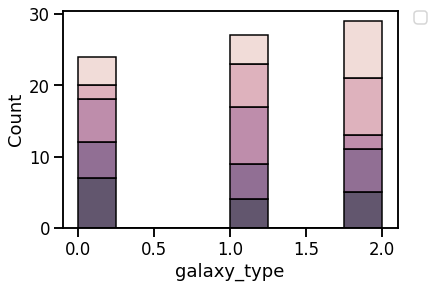

In [96]:
sns.histplot(x='galaxy_type',hue='block',multiple='stack',data=df_struc.query("planet<16"))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


In [98]:
file = open('../pickled_exp_parms/blocks/703632270.pkl','rb')
data= pickle.load(file)
exp_struc = data[0]
all_r_0 = data[1]
all_decay = data[2]
file.close()

In [99]:
exp_struc

[[[0],
  [1, 1],
  [0, 0],
  [1],
  [0, 0],
  [2, 2],
  [0, 0],
  [2],
  [0, 0],
  [2, 2],
  [1, 1],
  [0, 0]],
 [[2],
  [0],
  [2, 2, 2, 2],
  [1, 1],
  [2, 2, 2, 2, 2, 2],
  [0],
  [1, 1],
  [0],
  [1, 1, 1]],
 [[1],
  [2],
  [0, 0],
  [1],
  [2, 2],
  [1],
  [0, 0, 0],
  [2],
  [0],
  [1],
  [0, 0],
  [2, 2, 2],
  [0],
  [2]],
 [[1],
  [2],
  [0],
  [2, 2],
  [1],
  [0],
  [2, 2],
  [1],
  [0, 0, 0],
  [2, 2],
  [1],
  [0, 0, 0, 0],
  [2]],
 [[1], [2, 2, 2, 2, 2], [0], [1], [2, 2, 2, 2], [1, 1, 1, 1, 1, 1, 1, 1], [0]]]

In [77]:
df_struc = pd.DataFrame(columns=['condition','block','galaxy','planet','galaxy_type'])

for block in range(5):
    planet_in_block =0
    n_galaxy = len(exp_struc[block])
    print(n_galaxy)
    for galaxy in range(n_galaxy):
        curr_galaxy = exp_struc[block][galaxy] 
        for planet in range(len(curr_galaxy)):
            row = pd.DataFrame({'block':block,'galaxy':galaxy,'planet':planet_in_block,'galaxy_type':curr_galaxy[planet]},index=[0])
            df_struc = pd.concat([df_struc,row],ignore_index=True)
            planet_in_block+= 1

12
9
14
13
7


<AxesSubplot:xlabel='galaxy_type', ylabel='Count'>

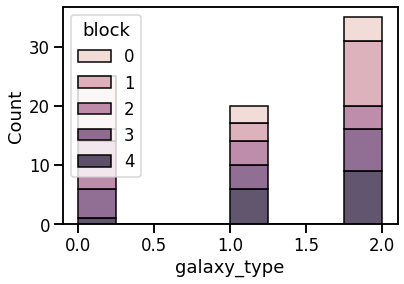

In [78]:
sns.histplot(x='galaxy_type',hue='block',multiple='stack',data=df_struc.query("planet<16"))


In [80]:
file = open('../pickled_exp_parms/blocks/102760073.pkl','rb')
# rich graded
data= pickle.load(file)
exp_struc = data[0]
all_r_0 = data[1]
all_decay = data[2]
file.close()

In [81]:
exp_struc

[[[1],
  [2],
  [1],
  [0],
  [2],
  [1, 1],
  [2, 2],
  [1],
  [2, 2, 2, 2, 2, 2],
  [1, 1, 1, 1, 1]],
 [[1, 1],
  [2, 2, 2, 2, 2],
  [1],
  [0],
  [2, 2],
  [1],
  [2, 2],
  [0],
  [1],
  [2],
  [1, 1, 1, 1]],
 [[1],
  [2],
  [1],
  [2],
  [1, 1, 1],
  [0],
  [2, 2, 2, 2, 2],
  [0],
  [1, 1],
  [2],
  [1, 1, 1, 1]],
 [[1],
  [0, 0, 0],
  [2],
  [0],
  [2, 2],
  [0, 0, 0, 0, 0],
  [2],
  [0, 0],
  [1],
  [0],
  [2],
  [0, 0]],
 [[1, 1, 1],
  [2],
  [1, 1],
  [2],
  [1, 1, 1, 1],
  [0],
  [2],
  [0, 0, 0],
  [1, 1],
  [2],
  [1],
  [2]]]

In [82]:
df_struc = pd.DataFrame(columns=['condition','block','galaxy','planet','galaxy_type'])

for block in range(5):
    planet_in_block =0
    n_galaxy = len(exp_struc[block])
    print(n_galaxy)
    for galaxy in range(n_galaxy):
        curr_galaxy = exp_struc[block][galaxy] 
        for planet in range(len(curr_galaxy)):
            row = pd.DataFrame({'block':block,'galaxy':galaxy,'planet':planet_in_block,'galaxy_type':curr_galaxy[planet]},index=[0])
            df_struc = pd.concat([df_struc,row],ignore_index=True)
            planet_in_block+= 1

10
11
11
12
12


<AxesSubplot:xlabel='galaxy_type', ylabel='Count'>

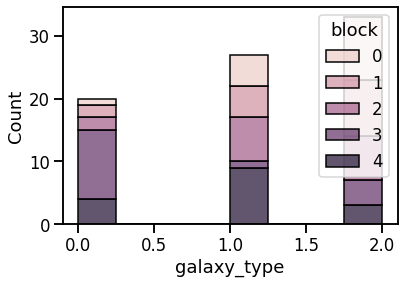

In [83]:
sns.histplot(x='galaxy_type',hue='block',multiple='stack',data=df_struc.query("planet<16"))


In [84]:
file = open('../pickled_exp_parms/blocks/70312457.pkl','rb')
# rich graded
data= pickle.load(file)
exp_struc = data[0]
all_r_0 = data[1]
all_decay = data[2]
file.close()

In [85]:
exp_struc

[[[0, 0],
  [1],
  [2],
  [0, 0, 0, 0, 0, 0, 0, 0],
  [2],
  [0, 0, 0],
  [2],
  [0, 0],
  [1],
  [0]],
 [[1, 1],
  [2],
  [1, 1],
  [0, 0],
  [1, 1, 1],
  [0, 0, 0, 0, 0, 0, 0],
  [2, 2],
  [0, 0]],
 [[0],
  [1],
  [2, 2, 2],
  [1],
  [0],
  [2, 2, 2, 2, 2],
  [1],
  [2],
  [0],
  [2, 2, 2, 2],
  [0],
  [2]],
 [[0, 0, 0],
  [2],
  [1, 1, 1, 1, 1],
  [2],
  [1],
  [0, 0],
  [1],
  [2, 2],
  [0, 0],
  [1, 1, 1]],
 [[0],
  [1],
  [2],
  [1, 1, 1],
  [0, 0, 0, 0],
  [2, 2],
  [1],
  [2],
  [0, 0, 0, 0],
  [2],
  [0, 0]]]

In [87]:
df_struc = pd.DataFrame(columns=['condition','block','galaxy','planet','galaxy_type'])

for block in range(5):
    planet_in_block =0
    n_galaxy = len(exp_struc[block])
    print(n_galaxy)
    for galaxy in range(n_galaxy):
        curr_galaxy = exp_struc[block][galaxy] 
        for planet in range(len(curr_galaxy)):
            row = pd.DataFrame({'block':block,'galaxy':galaxy,'planet':planet_in_block,'galaxy_type':curr_galaxy[planet]},index=[0])
            df_struc = pd.concat([df_struc,row],ignore_index=True)
            planet_in_block+= 1

10
8
12
10
11


<AxesSubplot:xlabel='galaxy_type', ylabel='Count'>

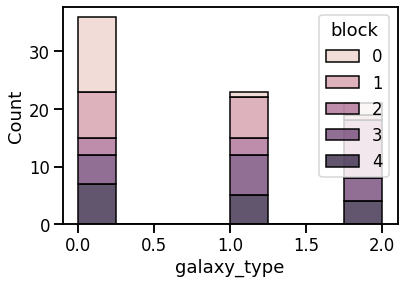

In [88]:
sns.histplot(x='galaxy_type',hue='block',multiple='stack',data=df_struc.query("planet<16"))


In [89]:
file = open('../pickled_exp_parms/blocks/750204647.pkl','rb')
# rich graded
data= pickle.load(file)
exp_struc = data[0]
all_r_0 = data[1]
all_decay = data[2]
file.close()

In [90]:
exp_struc

[[[0, 0],
  [1],
  [0, 0],
  [2],
  [0],
  [1],
  [0],
  [2],
  [0],
  [1, 1, 1],
  [2, 2],
  [1],
  [2, 2, 2],
  [1]],
 [[1],
  [0],
  [2],
  [1, 1],
  [0, 0],
  [1],
  [2, 2, 2],
  [0, 0, 0, 0, 0, 0, 0],
  [2],
  [1, 1]],
 [[2, 2, 2, 2, 2, 2],
  [1, 1, 1],
  [2, 2],
  [0],
  [2],
  [0],
  [2, 2, 2],
  [0],
  [1, 1],
  [0]],
 [[0],
  [1],
  [2],
  [0],
  [1, 1, 1, 1, 1],
  [0],
  [2, 2, 2, 2, 2, 2, 2, 2],
  [1],
  [0],
  [1]],
 [[2, 2, 2, 2, 2, 2, 2, 2],
  [1, 1],
  [2, 2],
  [0],
  [2],
  [0],
  [2, 2, 2],
  [0],
  [1],
  [0]]]

In [91]:
df_struc = pd.DataFrame(columns=['condition','block','galaxy','planet','galaxy_type'])

for block in range(5):
    planet_in_block =0
    n_galaxy = len(exp_struc[block])
    print(n_galaxy)
    for galaxy in range(n_galaxy):
        curr_galaxy = exp_struc[block][galaxy] 
        for planet in range(len(curr_galaxy)):
            row = pd.DataFrame({'block':block,'galaxy':galaxy,'planet':planet_in_block,'galaxy_type':curr_galaxy[planet]},index=[0])
            df_struc = pd.concat([df_struc,row],ignore_index=True)
            planet_in_block+= 1

14
10
10
10
10


No handles with labels found to put in legend.


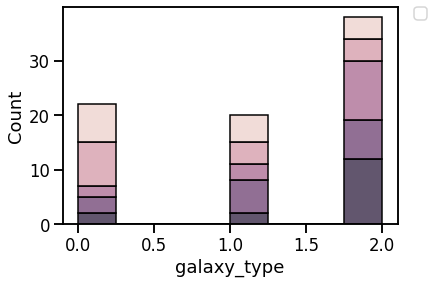

In [93]:
sns.histplot(x='galaxy_type',hue='block',multiple='stack',data=df_struc.query("planet<16"))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


In [27]:
def load_data(seed):
    file = open('../pickled_exp_parms/blocks/'+str(seed)+'.pkl','rb')
    data= pickle.load(file)
    exp_struc = data[0]
    rho0 = data[1]
    all_decay = data[2]
    file.close()
    return exp_struc,rho0, all_decay

def load_mdp(seed):
    file = open('../pickled_exp_parms/mdp_'+str(seed)+'.pkl','rb')
    data= pickle.load(file)
    all_change_points = data[0]
    all_n_cp = data[1]
    all_next_galaxy = data[2]
    all_counter = data[3]
    file.close()
    return all_change_points, all_n_cp, all_next_galaxy, all_counter

def flatten_list(list):
    new_list = [item for sublist in list for item in sublist]
    return new_list

def make_crp_sub_df(seed,params,sub_num):
    cluster_var = params[0]
    hyper_mu = params[1]
    num_particles = 25
    choices, all_reward_exp,true_planet = sim_crp.crp_beta(seed,params,num_particles,3)
    prts =  [sim_crp.get_prts(block) for block in choices]
    exp_struc, __,__ = load_data(seed)
    sub_df = pd.DataFrame(columns=['sub_num','cluster_var','hyper_mu','n_samples','block','galaxy','prt'])
    for block in range(5):
        n_planets = len(prts[block])
        tmp = pd.DataFrame({'sub_num':[sub_num]*n_planets,
                            'cluster_var':[cluster_var]*n_planets,'hyper_mu':[hyper_mu]*n_planets,
                           'n_samples':['low']*n_planets,'block':[block]*n_planets,'galaxy':flatten_list(exp_struc[block])[:n_planets],
                           'prt':prts[block]})
        sub_df = pd.concat([sub_df,tmp])

    sub_df['reward'] = all_reward_exp
    sub_df['true_planet'] = true_planet
    sub_df['opt_prt'],__,__,__,__ = sim.get_indiv_sub_prt(seed,true_planet,all_reward_exp)
    sub_df['opt_prt_om'],__,__,__,__ = sim.get_indiv_sub_prt_omniscent(seed,true_planet,all_reward_exp)

    return sub_df

def make_crp_df(seed,n_subs):
    sub_n = 0
    df = pd.DataFrame(columns=['sub_num','cluster_var','hyper_mu','n_samples','block','galaxy','prt','reward','true_planet','opt_prt','opt_prt_om'])
    for sub in range(n_subs):
        cluster_var = min(stats.halfnorm.rvs(loc=0.001,scale=0.01,size=1)[0],0.1)
        hyper_mu = max(min(stats.norm.rvs(loc=0.5,scale=0.1,size=1)[0],1),0.001)
        params = [cluster_var,hyper_mu]
        sub_df = make_crp_sub_df(seed,params,sub_n)
        df = pd.concat([df,sub_df])
        sub_n += 1
    return df


def make_bayes_sub_df(seed,params,sub_num):
    hyper_mu = params[0]
    hyper_var = params[1]
    choices, all_reward_exp,true_planet = sim_crp.bayes_beta(seed,params,3)
    prts =  [sim_crp.get_prts(block) for block in choices]
    exp_struc, __,__ = load_data(seed)
    sub_df = pd.DataFrame(columns=['sub_num','hyper_mu','hyper_var','n_samples','block','galaxy','prt'])
    for block in range(5):
        n_planets = len(prts[block])
        tmp = pd.DataFrame({'sub_num':[sub_num]*n_planets,
                            'hyper_mu':[hyper_mu]*n_planets,'hyper_var':[hyper_var]*n_planets,
                           'n_samples':['low']*n_planets,'block':[block]*n_planets,'galaxy':flatten_list(exp_struc[block])[:n_planets],
                           'prt':prts[block]})
        sub_df = pd.concat([sub_df,tmp])
    sub_df['reward'] = all_reward_exp
    sub_df['true_planet'] = true_planet
    sub_df['opt_prt'],__,__,__,__ = sim.get_indiv_sub_prt(seed,true_planet,all_reward_exp)
    sub_df['opt_prt_om'],__,__,__,__ = sim.get_indiv_sub_prt_omniscent(seed,true_planet,all_reward_exp)

    return sub_df

def make_bayes_df(seed,n_subs):
    sub_n = 0
    df = pd.DataFrame(columns=['sub_num','hyper_mu','hyper_var','n_samples','block','galaxy','prt','reward','true_planet','opt_prt','opt_prt_om'])
    for sub in range(n_subs):
        hyper_mu = max(min(stats.norm.rvs(loc=0.5,scale=0.1,size=1)[0],1),0.001)
        hyper_var = max(min(stats.norm.rvs(loc=0.1,scale=0.1,size=1)[0],1),0.001)
        params = [hyper_mu,hyper_var]
        sub_df = make_bayes_sub_df(seed,params,sub_n)
        df = pd.concat([df,sub_df])
        sub_n += 1
    return df

def run_sims(seed,n_sim=50):
    crp_df = make_crp_df(seed,n_sim)
    bayes_df = make_bayes_df(seed,n_sim)

    crp_df['prt_rel_mvt'] = crp_df['prt'] - crp_df['opt_prt']
    crp_df['prt_rel_mvt_om'] = crp_df['prt'] - crp_df['opt_prt_om']
    crp_df = crp_df.astype({'galaxy':'int','prt_rel_mvt':'int','prt_rel_mvt_om':'int'})

    bayes_df['prt_rel_mvt'] = bayes_df['prt'] - bayes_df['opt_prt']
    bayes_df['prt_rel_mvt_om'] = bayes_df['prt'] - bayes_df['opt_prt_om']
    bayes_df = bayes_df.astype({'galaxy':'int','prt_rel_mvt':'int','prt_rel_mvt_om':'int'})

    return crp_df, bayes_df

In [43]:
with open('sims_353653221.pkl', 'wb') as f_out:
    pickle.dump([crp_df_samp_low, bayes_df_samp_low,crp_df_samp_high, bayes_df_samp_high,
                         crp_df_beta_low, bayes_df_beta_low,crp_df_beta_high, bayes_df_beta_high],f_out)

In [7]:
file = open('sims_353653221.pkl','rb')
data= pickle.load(file)
crp_df_samp_low = data[0]
bayes_df_samp_low = data[1]
crp_df_samp_high = data[2] 
bayes_df_samp_high = data[3]


In [28]:
crp_df_samp_low, bayes_df_samp_low = run_sims(761411576,n_sim=50)

[0.005306237014548336, 0.486959215250127]
[0.002102985126636386, 0.46047970046559417]
[0.007794847568110284, 0.3811182831304869]
[0.00860018575510595, 0.3930218556485804]
[0.007499405875149354, 0.54288654284923]
[0.01155556681397324, 0.4327277800716767]
[0.009012263418215555, 0.3523705993385249]
[0.0016610857882606693, 0.5598764814505733]
[0.0023923761416146183, 0.46053238201837793]
[0.01206884587494345, 0.36913741379354925]
[0.019780605326012304, 0.7448756616241302]
[0.010892143842909242, 0.636400465407811]
[0.0013049843589958137, 0.5318972016295995]
[0.008564615135327292, 0.5122847585929958]
[0.002386548433884835, 0.7026632011053688]
[0.009734891233612288, 0.6834934404259161]
[0.0018762341387891682, 0.5977683092414652]
[0.00845271022748243, 0.5158052022518598]
[0.013115240096008871, 0.6311451916624762]
[0.007443520369961899, 0.41248699514362935]
[0.0029453099245227545, 0.6235764056169479]
[0.004401429247029364, 0.5185581026627327]
[0.005878726945549849, 0.5000837185118552]
[0.0104017

In [6]:
crp_df_samp_high, bayes_df_samp_high = run_sims(353653221,n_sim=50)

[0.0033639759271382953, 0.4281992005011759]
[0.006105662200753271, 0.39292923683636133]
[0.0038965734572793983, 0.6569373072622531]
[0.003457400637872208, 0.6276728893152306]
[0.0002747622660086664, 0.4662760085892363]
[0.005931240991963226, 0.4607268123781593]
[0.009832957156391445, 0.4595255189474362]
[0.007438600629765558, 0.4707940558005357]
[0.00150017294230387, 0.5397619235292453]
[0.006315954660537785, 0.45486866064430315]
[0.005318478455593746, 0.43833035149763144]
[0.0025993522083383063, 0.49389828516635365]
[0.014878917145628709, 0.4356003172126868]
[0.003182356143520387, 0.4221026893114401]
[0.008185824336969901, 0.5784148841177619]
[0.008178000644240659, 0.7495145163821122]
[0.0027728673375658104, 0.4711224290004136]
[0.015327826984622874, 0.4099274768742199]
[0.008526114893664508, 0.5995025793144634]
[0.0036940615901587554, 0.5784767825238644]
[0.014529089100987805, 0.39817476062675305]
[0.00678725775580165, 0.37916074012409606]
[0.01147715992909907, 0.5313495963480788]
[0

In [3]:
crp_df_beta_low, bayes_df_beta_low = run_sims(353653221,n_sim=50)

[0.004118062338466952, 0.4961253568139494]
[0.012116339914569715, 0.5263576245684268]
[0.017147055399911983, 0.5367968919473991]
[0.011002468780881338, 0.3983009886892237]
[0.000630669247902471, 0.5378489549750956]
[0.00022380066820465078, 0.4402864013892226]
[0.0003531701090474834, 0.40745861488984764]
[0.011881539300445278, 0.5256846388770273]
[0.0021381958855963747, 0.3314882183181714]
[0.014891872016870802, 0.4017614412573797]
[0.016360807007522384, 0.3905007051853671]
[0.007847819196192167, 0.4184838275715712]
[0.011398692908069706, 0.7132595460248431]
[0.024931334139726303, 0.5222308086092767]
[0.004923938917502954, 0.44179463788959317]
[0.014005257129489988, 0.3413325735053859]
[0.0076494757477699364, 0.5365903111114313]
[0.005307831443248785, 0.6185344931153333]
[0.0003381530343565604, 0.5629781917373298]
[0.0004958053148038272, 0.5700572680984077]
[0.014680315420017652, 0.29208645853052423]
[0.002628897640468127, 0.705462198486668]
[0.006962533626407766, 0.5032131004044867]
[0

In [8]:
crp_df_beta_high, bayes_df_beta_high = run_sims(353653221,n_sim=50)

[0.006693039653170333, 0.5683301410173597]
[0.008644144064677391, 0.5100562587636206]
[0.012081817406667986, 0.410744192545756]
[0.006650735471977303, 0.6668524598278375]
[0.01601957587454641, 0.5486450316723986]
[0.02305413893850443, 0.7889793632914692]
[0.004530625416078716, 0.7236158513193262]
[0.006857557959645034, 0.477305055779416]
[0.0022263584340539, 0.48139885288999124]
[0.0036057889017283304, 0.5591615004699774]
[0.011790270882877714, 0.4613957041211014]
[0.017842019070869238, 0.4763941823370422]
[0.015686099843616196, 0.4679030856974349]
[0.006595794958755023, 0.7131604327850913]
[0.03181273266587339, 0.37325882018495027]
[0.01232473173591819, 0.524495186549167]
[0.0038506117724072223, 0.5090500181509926]
[0.025394675008153855, 0.5053192564931385]
[0.010270528878856707, 0.5724468971095005]
[0.014362880091307689, 0.5107532706084216]
[0.0020937318008908395, 0.650790025403959]
[0.004588826996734845, 0.46442737054097866]
[0.004774290901992261, 0.560170938946985]
[0.0074510850362

In [26]:
crp_df_beta_high

,sub_num,cluster_var,hyper_mu,n_samples,block,galaxy,prt,reward,true_planet,opt_prt,opt_prt_om,beta,prt_rel_mvt,prt_rel_mvt_om
0,0,0.006693,0.568330,NaN,0,0,2,"[102.62970558999567, 39.97940323264509]",0,2,1,high,0,1
1,0,0.006693,0.568330,NaN,0,0,1,[89.14801348577944],1,2,1,high,-1,0
2,0,0.006693,0.568330,NaN,0,0,1,[106.52908547935098],2,2,3,high,-1,-2
3,0,0.006693,0.568330,NaN,0,0,1,[108.82001103709936],3,2,3,high,-1,-2
4,0,0.006693,0.568330,NaN,0,0,1,[95.66269159579342],4,2,3,high,-1,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,49,0.008713,0.501528,NaN,4,1,2,"[101.92079705920504, 61.17418763050421]",95,2,2,high,0,0
16,49,0.008713,0.501528,NaN,4,0,2,"[91.58833790903377, 35.187975540449514]",96,2,2,high,0,0
17,49,0.008713,0.501528,NaN,4,0,2,"[101.91291433074927, 24.67772232906188]",97,2,2,high,0,0
18,49,0.008713,0.501528,NaN,4,0,1,[97.8570079186752],98,2,4,high,-1,-3


In [25]:
avg=crp_df_beta_high.groupby(by=['sub_num','hyper_mu']).prt_rel_mvt.mean()
avg

sub_num  hyper_mu
0        0.568330   -0.173913
1        0.510056    0.021978
2        0.410744   -0.021978
3        0.666852   -0.096774
4        0.548645    0.123596
5        0.788979    0.111111
6        0.723616   -0.065934
7        0.477305   -0.139785
8        0.481399    0.134831
9        0.559162   -0.120879
10       0.461396   -0.380435
11       0.476394    0.077778
12       0.467903    0.147727
13       0.713160   -0.088889
14       0.373259   -0.032258
15       0.524495    0.147727
16       0.509050   -0.075269
17       0.505319   -0.064516
18       0.572447    0.077778
19       0.510753    0.125000
20       0.650790   -0.078652
21       0.464427   -0.032967
22       0.560171   -0.141304
23       0.276242   -0.032609
24       0.564979   -0.043956
25       0.562079    0.054945
26       0.476432    0.136364
27       0.642389   -0.056180
28       0.430896    0.022222
29       0.624538   -0.130435
30       0.384177   -0.161290
31       0.465249   -0.065217
32       0.500617   -0

In [11]:
crp_df_samp_low['model'] = 'crp'
bayes_df_samp_low['model'] = 'bayes'
crp_df_samp_high['model'] = 'crp'
bayes_df_samp_high['model'] = 'bayes'
crp_df_beta_low['model'] = 'crp'
bayes_df_beta_low['model'] = 'bayes'
crp_df_beta_high['model'] = 'crp'
bayes_df_beta_high['model'] = 'bayes'

In [12]:
all_the_sims = pd.concat([crp_df_samp_low, bayes_df_samp_low,crp_df_samp_high, bayes_df_samp_high,
                         crp_df_beta_low, bayes_df_beta_low,crp_df_beta_high, bayes_df_beta_high])

<AxesSubplot:xlabel='beta', ylabel='prt_rel_mvt'>

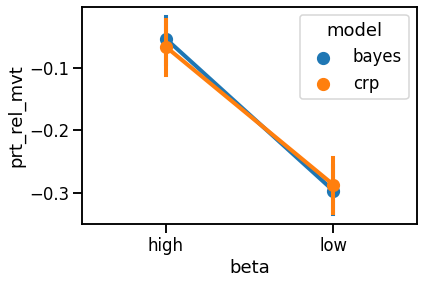

In [14]:
avg = all_the_sims.groupby(by=['sub_num','model','beta']).prt_rel_mvt.mean().reset_index()
sns.pointplot(x='beta',y='prt_rel_mvt',hue='model',data=avg)

<AxesSubplot:xlabel='beta', ylabel='prt_rel_mvt_om'>

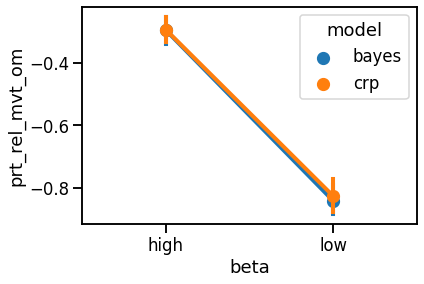

In [17]:
avg = all_the_sims.groupby(by=['sub_num','model','beta']).prt_rel_mvt_om.mean().reset_index()
sns.pointplot(x='beta',y='prt_rel_mvt_om',hue='model',data=avg)

<AxesSubplot:xlabel='n_samples', ylabel='prt_rel_mvt'>

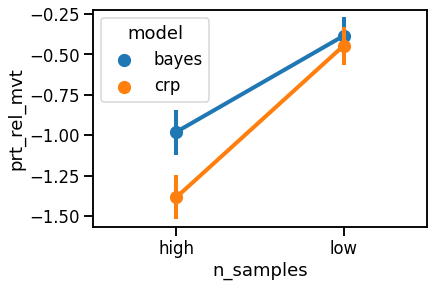

In [16]:
avg = all_the_sims.groupby(by=['sub_num','model','n_samples']).prt_rel_mvt.mean().reset_index()
sns.pointplot(x='n_samples',y='prt_rel_mvt',hue='model',ci=68,data=avg)

<AxesSubplot:xlabel='n_samples', ylabel='prt_rel_mvt_om'>

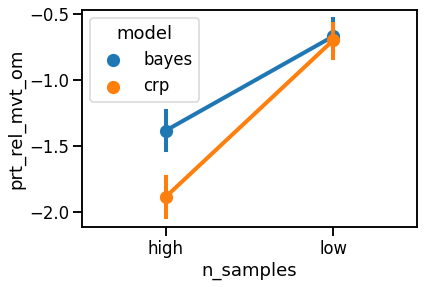

In [18]:
avg = all_the_sims.groupby(by=['sub_num','model','n_samples']).prt_rel_mvt_om.mean().reset_index()
sns.pointplot(x='n_samples',y='prt_rel_mvt_om',hue='model',ci=68,data=avg)

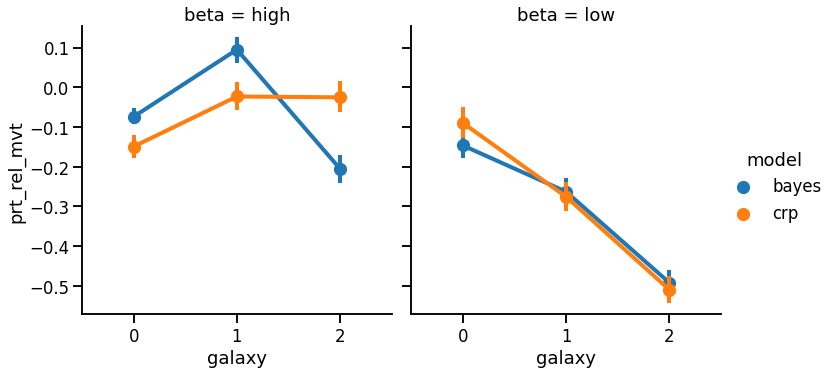

In [19]:
avg = all_the_sims.groupby(by=['sub_num','model','beta','galaxy']).prt_rel_mvt.mean().reset_index()
sns.catplot(x='galaxy',y='prt_rel_mvt',hue='model',col='beta',kind='point',ci=68,data=avg)

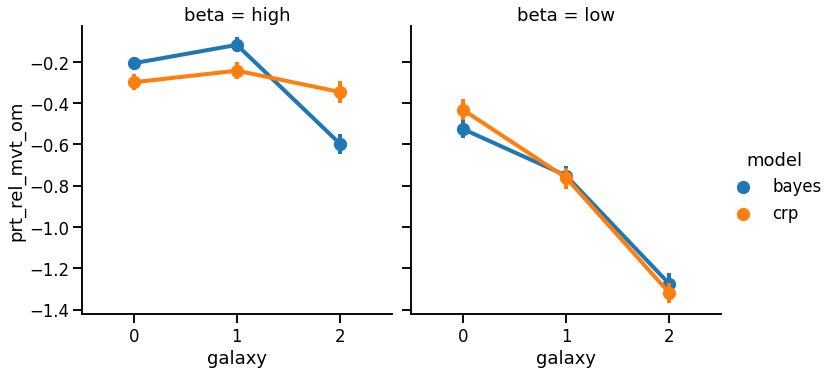

In [20]:
avg = all_the_sims.groupby(by=['sub_num','model','beta','galaxy']).prt_rel_mvt_om.mean().reset_index()
sns.catplot(x='galaxy',y='prt_rel_mvt_om',hue='model',col='beta',kind='point',ci=68,data=avg)

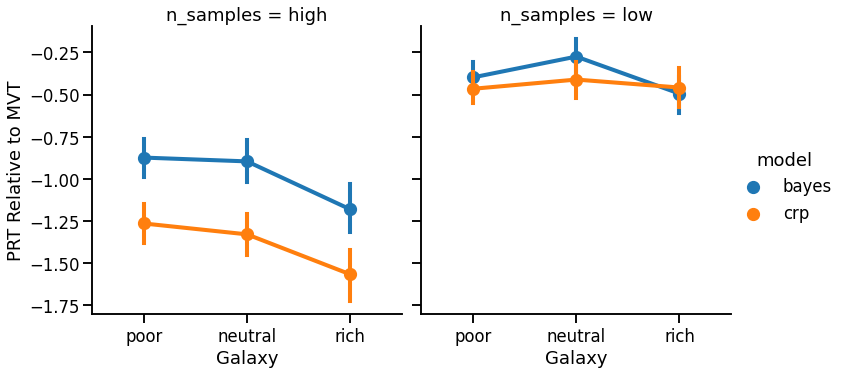

In [41]:
avg = all_the_sims.groupby(by=['sub_num','model','n_samples','galaxy']).prt_rel_mvt.mean().reset_index()
g=sns.catplot(x='galaxy',y='prt_rel_mvt',hue='model',col='n_samples',kind='point',ci=68,data=avg)
g.set_axis_labels("Galaxy", "PRT Relative to MVT")
g.set_xticklabels(['poor','neutral','rich'])


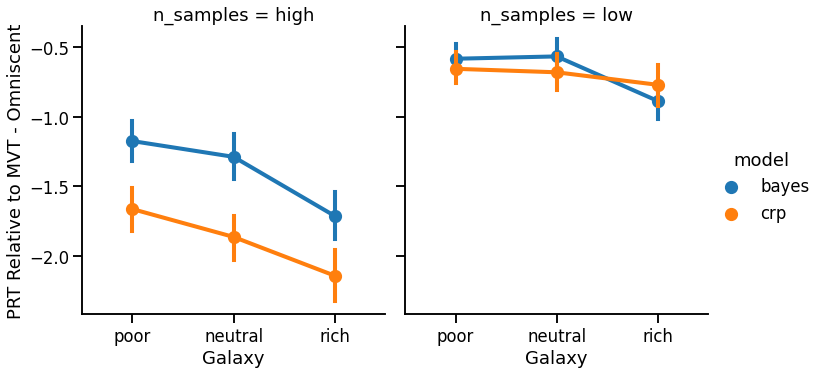

In [42]:
avg = all_the_sims.groupby(by=['sub_num','model','n_samples','galaxy']).prt_rel_mvt_om.mean().reset_index()
g=sns.catplot(x='galaxy',y='prt_rel_mvt_om',hue='model',col='n_samples',kind='point',ci=68,data=avg)
g.set_axis_labels("Galaxy", "PRT Relative to MVT - Omniscent")
g.set_xticklabels(['poor','neutral','rich'])

In [45]:
def crp_samples(seed,params,num_particles,n_samples,harvest_time=2,iti=1.5,travel_time=8.5,exp_time=100000,eps=0.0000000001):
    print(params)
    #condition = condition_type(cond_num)
    ___, rho_0, all_decay = load_data(seed)

    alpha = 0.1
    cluster_var = params[0]
    hyper_mu = params[1]

    state = pf.initial_state(num_particles,alpha,cluster_var,hyper_mu=hyper_mu)

    # save important variables here
    choices = []
    all_reward_exp = [] # reward list of the simulation
    n_blocks = 5
    block_max = 300
    n_planets = 20

    total_reward = 0
    total_time = 3.5

    planet = 0
    true_planet = []
    max_k = state["max_k"]
    post = np.concatenate((np.ones((num_particles,1)),np.zeros((num_particles,max_k-1))),axis=1)

    for block in range(n_blocks):
        block_time, planet, prt, block_choice = initialize_block()
        while (block_time < block_max) & (planet < n_planets):
            reward_exp, on_planet, reward, true_planet, planet_decay = initialize_planet(rho_0,block,planet,true_planet)
            while (block_time < block_max) & on_planet:
                total_reward += reward
                reward_exp.append(reward)
                block_time += (harvest_time+iti)
                total_time += (harvest_time+iti)
                # calc decay experienced
                if prt > 0:
                    actual_decay = all_decay[block][planet][prt-1]
                    planet_decay.append(actual_decay) # save for inference over which patch type we're in

                    # do inference on which cluster in
                    curr_prior = pf.prior(state) # retrieve prior expectation of being in a state
                    log_prior = np.log(curr_prior+eps)
                    curr_log_likelihood = pf.log_likelihood(state,planet_decay)
                    post = pf.posterior(log_prior,curr_log_likelihood)

                expec_decay_mu, expec_decay_var = infer_cluster(state,pf.normalize(post+eps))
                print('decay_mu: ' + str(expec_decay_mu))
                print('decay_var: ' + str(expec_decay_var))
                v_stay_mu = expec_decay_mu*reward
                v_stay_var = expec_decay_var*(reward**2)
                print('v_stay_mu: ' + str(v_stay_mu))
                print('v_stay_var: ' + str(v_stay_var))


                v_leave_mu = (total_reward/total_time)*(harvest_time+iti)
                v_leave_var =(total_reward/(total_time**2))*((harvest_time+iti)**2)
                print('v_leave_mu: ' + str(v_leave_mu))
                print('v_leave_var: ' + str(v_leave_var))


                stay_samples = sample_from_dist(v_stay_mu,v_stay_var,n_samples)
                leave_samples = sample_from_dist(v_leave_mu,v_leave_var,n_samples)

                if stay_samples > leave_samples:
                    prob_stay = 1
                else:
                    prob_stay = 0
                print('prob stay: ' +str(prob_stay))


                curr_prt = prt
                choice, on_planet, prt = make_choice(prob_stay,prt)
                block_choice.append(choice)
                reward = reward*all_decay[block][planet][prt]

            # update params for monitoring environment reward rate
            if (curr_prt > 0) & (on_planet==False):
                pf.resample_and_update_particles(state,post,planet_decay)
            all_reward_exp.append(reward_exp)
            planet += 1
            block_time += travel_time
            total_time += travel_time
        choices.append(block_choice)
    return choices, all_reward_exp,true_planet

In [2]:
import particle_filter as pf
sim_crp.crp_samples(353653221,[0.0049,0.55],50,3)

[0.0049, 0.55]
decay_mu: 0.5499999999999998
decay_var: 0.10000000000000009
v_stay_mu: 56.446338074497596
v_stay_var: 1053.2856469489197
v_leave_mu: 51.31485279499783
v_leave_var: 25.657426397498917
prob stay: 1
actual decay: 0.20054042915902914
decay_mu: 0.55
decay_var: 0.09999999999999953
v_stay_mu: 21.988671777954803
v_stay_var: 159.8352682838425
v_leave_mu: 47.536369607546916
v_leave_var: 15.845456535848975
prob stay: 0
decay_mu: 0.21358462993637553
decay_var: 0.008652570205447421
v_stay_mu: 19.040645469923216
v_stay_var: 68.76516223750424
v_leave_mu: 36.05110791464315
v_leave_var: 5.6079501200556
prob stay: 0
decay_mu: 0.21358462993637553
decay_var: 0.008652570205447421
v_stay_mu: 22.752975299567694
v_stay_var: 98.19322619689376
v_leave_mu: 34.31889064513621
v_leave_var: 3.481626587187731
prob stay: 0
decay_mu: 0.21358462993637553
decay_var: 0.008652570205447421
v_stay_mu: 23.242281787031168
v_stay_var: 102.46196088379743
v_leave_mu: 33.653156255635416
v_leave_var: 2.53303326655320

decay_mu: 0.6090362744206139
decay_var: 0.006108124244974145
v_stay_mu: 59.13136539748809
v_stay_var: 57.57810361335826
v_leave_mu: 34.63750516588485
v_leave_var: 0.33489300574750547
prob stay: 1
actual decay: 0.741099111545479
decay_mu: 0.6088100762633505
decay_var: 0.011300156624082902
v_stay_mu: 37.61827068508057
v_stay_var: 43.1438059360298
v_leave_mu: 34.89751374167181
v_leave_var: 0.3341759181829038
prob stay: 1
actual decay: 0.6364176977419032
decay_mu: 0.6114169829808651
decay_var: 0.006875506972443213
v_stay_mu: 27.900923888128414
v_stay_var: 14.317490386227465
v_leave_mu: 34.99934290577634
v_leave_var: 0.3319720871821604
prob stay: 0
decay_mu: 0.6179085696270616
decay_var: 0.006845500698972384
v_stay_mu: 60.31837802799652
v_stay_var: 65.23130874125094
v_leave_mu: 34.79374544959645
v_leave_var: 0.3196275828703086
prob stay: 1
actual decay: 0.40867423088922294
decay_mu: 0.41585838963864424
decay_var: 0.013407249956580575
v_stay_mu: 23.395248924538354
v_stay_var: 42.433036613710

decay_mu: 0.5481128414870989
decay_var: 0.01850046728117849
v_stay_mu: 54.45311844571184
v_stay_var: 182.59473721907716
v_leave_mu: 35.18910577184298
v_leave_var: 0.19410854247667525
prob stay: 1
actual decay: 0.5746334367118773
decay_mu: 0.6254914277746131
decay_var: 0.007907520780122523
v_stay_mu: 34.13505264767451
v_stay_var: 23.55042622575222
v_leave_mu: 35.2954447052186
v_leave_var: 0.19362704775590145
prob stay: 1
actual decay: 0.5493212956900955
decay_mu: 0.6191751867078856
decay_var: 0.006819731238397686
v_stay_mu: 19.37375145210959
v_stay_var: 6.676788506944214
v_leave_mu: 35.27358903272751
v_leave_var: 0.1924513820959412
prob stay: 0
decay_mu: 0.6172977702839989
decay_var: 0.006815451056445487
v_stay_mu: 64.67059605284041
v_stay_var: 74.80298253018208
v_leave_mu: 35.18696470553407
v_leave_var: 0.18845352175878996
prob stay: 1
actual decay: 0.5926707966760393
decay_mu: 0.6286214810653472
decay_var: 0.007738439977661882
v_stay_mu: 36.92473691864784
v_stay_var: 26.69991033030609

decay_mu: 0.6551020976138257
decay_var: 0.008334562019078284
v_stay_mu: 60.78921133489065
v_stay_var: 71.7658479313343
v_leave_mu: 35.42718869912395
v_leave_var: 0.13219100260867148
prob stay: 1
actual decay: 0.6506212630314148
decay_mu: 0.6468243653226818
decay_var: 0.006660525340326462
v_stay_mu: 33.50988980010779
v_stay_var: 17.876469081573294
v_leave_mu: 35.48807938579025
v_leave_var: 0.1319259456720827
prob stay: 0
decay_mu: 0.6484339607110894
decay_var: 0.006669409242272384
v_stay_mu: 67.22437142462856
v_stay_var: 71.68187597600257
v_leave_mu: 35.42200140690809
v_leave_var: 0.13002307805367416
prob stay: 1
actual decay: 0.7760295141471656
decay_mu: 0.6614010641880854
decay_var: 0.0084971841546993
v_stay_mu: 57.58486676058696
v_stay_var: 64.41128812924588
v_leave_mu: 35.61087330417222
v_leave_var: 0.13023830362027458
prob stay: 1
actual decay: 0.8398127796680855
decay_mu: 0.6692572969348105
decay_var: 0.01314148147135863
v_stay_mu: 35.92290126973155
v_stay_var: 37.861769430234936


decay_mu: 0.6021372886748219
decay_var: 0.011188064095650374
v_stay_mu: 58.899253882920256
v_stay_var: 107.04921502367192
v_leave_mu: 36.20519869998239
v_leave_var: 0.10450985191747494
prob stay: 1
actual decay: 0.4064055863467457
decay_mu: 0.41257510508944106
decay_var: 0.007457414923580208
v_stay_mu: 23.675846234572287
v_stay_var: 24.558016738767986
v_leave_mu: 36.26616186063997
v_leave_var: 0.10438451193440781
prob stay: 0
decay_mu: 0.41305431498294554
decay_var: 0.007445853627396387
v_stay_mu: 40.4742267849075
v_stay_var: 71.49197408874868
v_leave_mu: 36.19105019631067
v_leave_var: 0.10315038736733496
prob stay: 0
decay_mu: 0.41305431498294554
decay_var: 0.007445853627396387
v_stay_mu: 40.17793999780819
v_stay_var: 70.44910812912123
v_leave_mu: 36.1153676490317
v_leave_var: 0.10193853771904107
prob stay: 1
actual decay: 0.32221324763465975
decay_mu: 0.40625079351046045
decay_var: 0.007200633212436636
v_stay_mu: 20.974900079922744
v_stay_var: 19.194731698055772
v_leave_mu: 36.159036

([[0,
   1,
   1,
   1,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   0,
   0,
   1,
   0,
   1,
   0,
   0,
   1],
  [0,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   1],
  [0,
   1,
   0,
   0,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   1,
   1,
   0,
   1,
   0,
   1,
   1,
   0,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   1,
   0,
   1,
   0,
   1],
  [0,
   0,
   1,
   0,
   1,
   0,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
 

# make sure meets sequence conditions

In [ ]:
df = pd.DataFrame(columns=['condition','block','galaxy','planet','galaxy_type'])
all_conds = ['poor_graded','poor_extreme','rich_graded','rich_extreme']
for cond in all_conds:
    exp_struc,rho0, all_decay = load_data(cond,196855274)
    for block in range(5):
        planet_in_block =0
        n_galaxy = len(exp_struc[block])
        print(n_galaxy)
        for galaxy in range(n_galaxy):
            curr_galaxy = exp_struc[block][galaxy] 
            for planet in range(len(curr_galaxy)):
                if block < 2:
                    block_stage = 'early'
                else:
                    block_stage = 'late'
                row = pd.DataFrame({'condition':cond,'block':block_stage,'galaxy':galaxy,'planet':planet_in_block,'galaxy_type':curr_galaxy[planet]},index=[0])
                df = pd.concat([df,row],ignore_index=True)
                planet_in_block+= 1

In [380]:
galaxy_counts = df.groupby(by=['condition','block','galaxy_type']).galaxy.count().reset_index()

In [381]:
df = df.query("planet < 16")

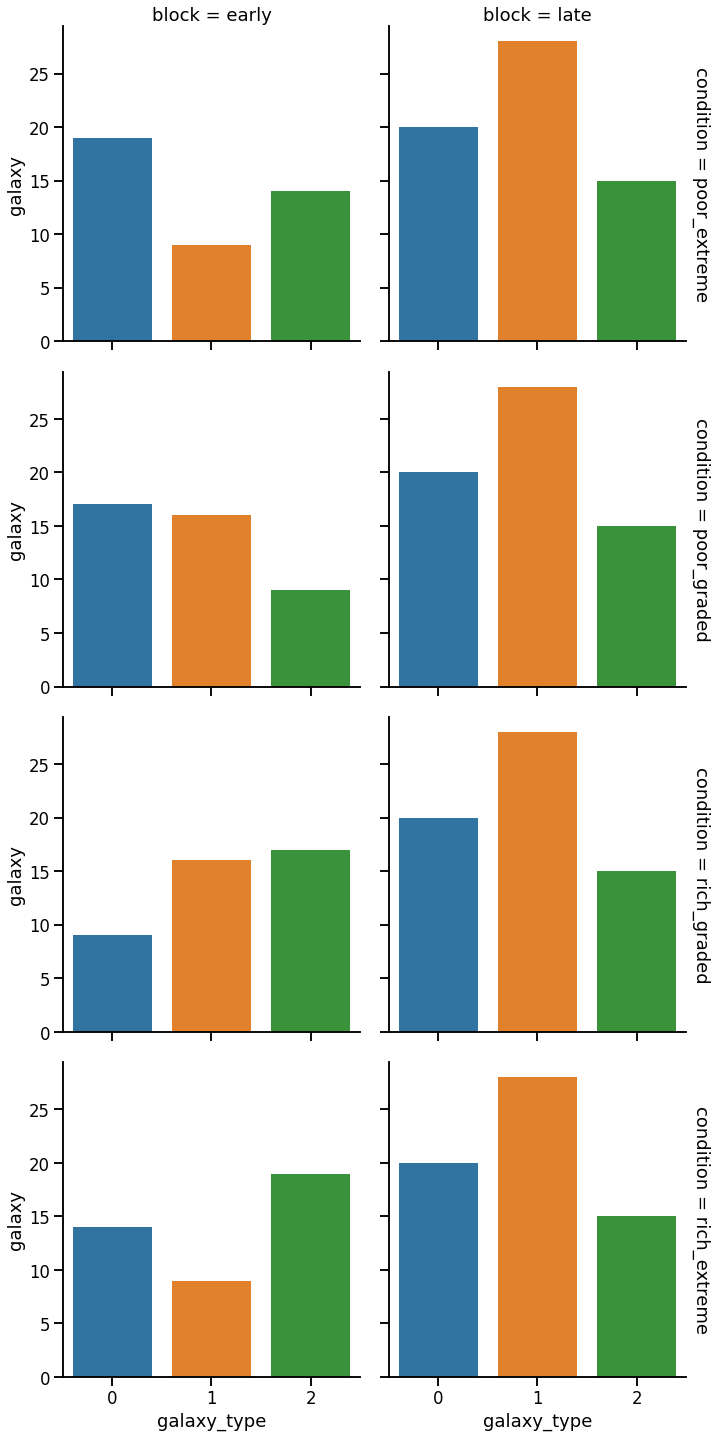

In [382]:
sns.catplot(x='galaxy_type',y='galaxy',row='condition',col='block',row_order = ['poor_extreme','poor_graded']+all_conds[2:],kind='bar',margin_titles=True,data=galaxy_counts)
plt.savefig('../plots/galaxy_counts.png',dpi=72)

In [26]:
df_2 = pd.DataFrame(columns=['condition','block','transition','transition_num'])
all_conds = ['poor_graded','poor_extreme','neutral_graded','neutral_extreme','rich_graded','rich_extreme']
for cond in all_conds:
    exp_struc,rho0, all_decay = load_data(cond)
    for block in range(6):
        transition_num = 0
        for galaxy in range(3):
            curr_galaxy_type = exp_struc[block][galaxy][0]
            next_galaxy_type = exp_struc[block][galaxy+1][0]

            if block < 2:
                block_stage = 'early'
            else:
                block_stage = 'late'
            
            if abs(curr_galaxy_type - next_galaxy_type) >= 2:
                transition_type = 'extreme'
            else:
                transition_type = 'graded'
                
            row = pd.DataFrame({'condition':cond,'block':block_stage,'transition':transition_type,'transition_num':transition_num},index=[0])
            df_2 = pd.concat([df_2,row],ignore_index=True)
            
            transition_num+= 1


In [27]:
transition_counts = df_2.groupby(by=['condition','block','transition']).transition_num.count().reset_index()

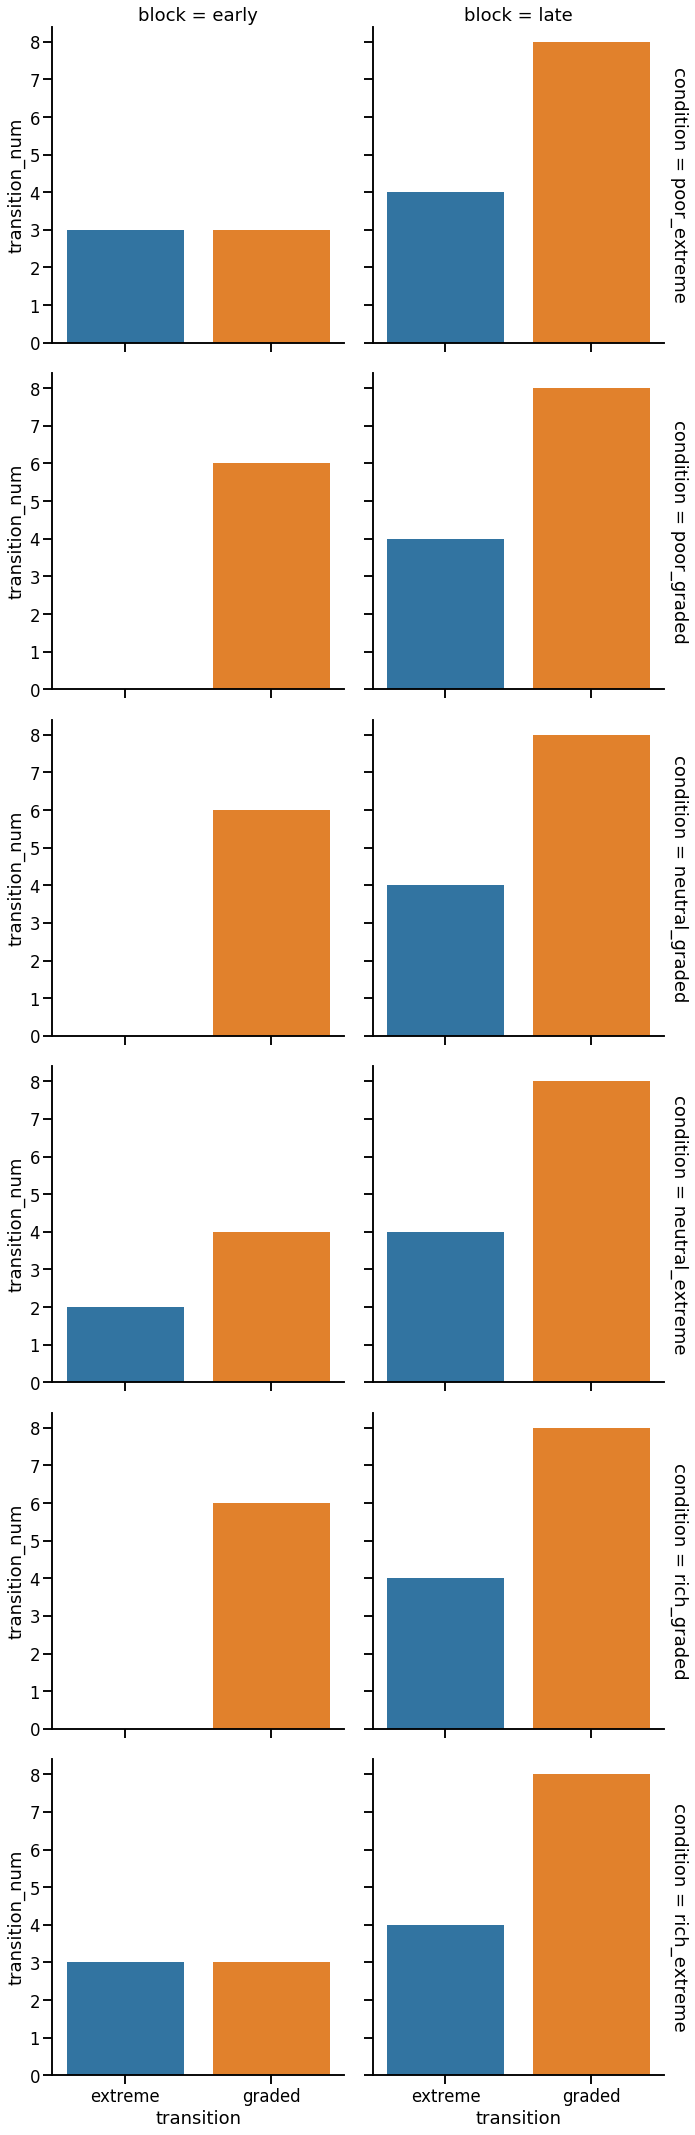

In [143]:
sns.catplot(x='transition',y='transition_num',row='condition',col='block',row_order = ['poor_extreme','poor_graded']+all_conds[2:]
,kind='bar',margin_titles=True,data=transition_counts)
plt.savefig('../plots/transition_counts.png',dpi=72)

In [384]:
all_reward_list = {}

for cond in all_conds:
    r = sim.create_reward_trajectories(cond)
    all_reward_list[cond] = r

IndexError: list index out of range

In [383]:
treasure_1 = []
treasure_2 = []
treasure_3 = []
treasure_4 = []
treasure_5 = []
treasure_6 = []
n_sim = 50
for s in range(n_sim):
    treasure_1.append(sim.sim(all_reward_list['poor_graded'],exp_struc)[0])
    treasure_2.append(sim.sim(all_reward_list['poor_extreme'],exp_struc)[0])
    treasure_3.append(sim.sim(all_reward_list['neutral_graded'],exp_struc)[0])
    treasure_4.append(sim.sim(all_reward_list['neutral_extreme'],exp_struc)[0])
    treasure_5.append(sim.sim(all_reward_list['rich_graded'],exp_struc)[0])
    treasure_6.append(sim.sim(all_reward_list['rich_extreme'],exp_struc)[0])
t_df = pd.DataFrame({'cond':['poor_graded']*n_sim+ ['poor_extreme']*n_sim+['neutral_graded']*n_sim +['neutral_extreme']*n_sim +['rich_graded']*n_sim + ['rich_extreme']*n_sim, 'total_reward':treasure_1+treasure_2+treasure_3+treasure_4+treasure_5+treasure_6})

NameError: name 'all_reward_list' is not defined

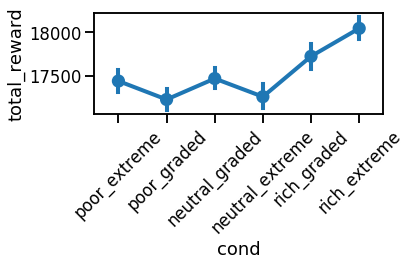

In [137]:
g=sns.pointplot(x='cond',y='total_reward',data=t_df)
g.set_xticklabels(['poor_extreme','poor_graded']+all_conds[2:])
g.set_xticklabels(g.get_xticklabels(),rotation=45)
plt.tight_layout()
plt.savefig('../plots/total_reward_across_exp.png')


In [98]:
def flatten_list(lst):
    flat_list = [item for sublist in lst for item in sublist]
    return flat_list

def sim(reward_trajectories,exp_struc):
    total_treasure = 0
    late_treasure = 0
    total_time = 0.5
    max_block_time = 300

    harvest_time = 2
    travel_time = 13.5
    iti = 1.5

    k=[1]
    prts=[]
    blocks =[]
    galaxy_types=[]


    for block in range(6):
        t = 0
        planet = 0
        r = 0
        curr_block = flatten_list(exp_struc[block])

        while (t < max_block_time) & (planet < 20):
            curr_trajectory = reward_trajectories[block][planet]

            curr_dig = curr_trajectory[r]

            total_treasure += curr_dig
            
            if block >1:
                late_treasure+= curr_dig
            
            if r > 0:
                k.append(curr_trajectory[r]/curr_trajectory[r-1])
            if r > 44:
                curr_dig = 0

            v_stay = curr_dig*(sum(k)/len(k))
            v_leave = ((total_treasure/total_time)*(harvest_time+iti))

            p_stay = v_stay/(v_stay +v_leave)

            choice = stats.bernoulli(p_stay).rvs()

            if choice == 0:
                prts.append(r)
                blocks.append(block)
                galaxy_types.append(curr_block[planet])
                r=0
                planet += 1
                t += travel_time
                total_time += travel_time
            else:
                r+=1
                t += (harvest_time + iti)
                total_time += (harvest_time + iti)

    return total_treasure,prts,blocks,galaxy_types,late_treasure


In [100]:
t_df_late = pd.DataFrame(columns=['cond','total_reward'])
n_sim = 50
for cond in all_conds:
    print(cond)
    exp_struc, __,__ = load_data(cond)
    for s in range(n_sim):
        sim_result = sim(all_reward_list[cond],exp_struc)
        tr = sim_result[-1]

        row= pd.DataFrame({'cond':cond,'total_reward':tr},index=[0])
        t_df_late = pd.concat([t_df_late,row],ignore_index=False)

poor_graded
poor_extreme
neutral_graded
neutral_extreme
rich_graded
rich_extreme


In [101]:
t_df_late

,cond,total_reward
0,poor_graded,11399.279336
0,poor_graded,11492.842611
0,poor_graded,11633.131039
0,poor_graded,12083.211871
0,poor_graded,12448.319550
...,...,...
0,rich_extreme,11750.359763
0,rich_extreme,12924.799309
0,rich_extreme,12513.608566
0,rich_extreme,11550.057599


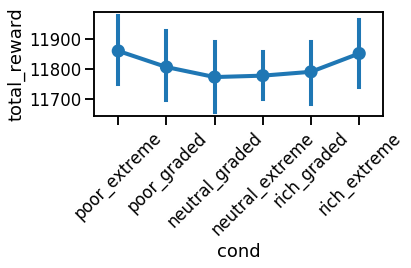

In [138]:
g=sns.pointplot(x='cond',y='total_reward',data=t_df_late)
g.set_xticklabels(['poor_extreme','poor_graded']+all_conds[2:])
g.set_xticklabels(g.get_xticklabels(),rotation=45)
plt.tight_layout()
plt.savefig('../plots/total_reward_late_slow_reversal.png')

In [104]:
prts = pd.DataFrame(columns=['condition','n_sim','planet','prt'])
n_sim =50
for cond in all_conds:
    exp_struc, __,__ = load_data(cond)
    for s in range(n_sim):
        sim_result = sim(all_reward_list[cond],exp_struc)
        prt = sim_result[1]
        block=sim_result[2]
        galaxy_type=sim_result[3]
        n = len(prt)
        row = pd.DataFrame({'condition':[cond]*n,'n_sim':[s]*n,'block':block,'galaxy_type':galaxy_type,'planet':list(range(n)),'prt':prt})
        prts = pd.concat([prts,row],ignore_index=True)

/Library/Frameworks/Python.framework/Versions/3.6/lib/python3.6/site-packages/ipykernel_launcher.py:12: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

  if sys.path[0] == '':


In [109]:
n_plan = prts.groupby(by=['condition','galaxy_type','n_sim']).planet.count().reset_index()

In [110]:
prts

,block,condition,galaxy_type,n_sim,planet,prt
0,0.0,poor_graded,0.0,0,0,0
1,0.0,poor_graded,0.0,0,1,0
2,0.0,poor_graded,0.0,0,2,0
3,0.0,poor_graded,0.0,0,3,1
4,0.0,poor_graded,0.0,0,4,2
...,...,...,...,...,...,...
30558,5.0,rich_extreme,1.0,49,95,2
30559,5.0,rich_extreme,1.0,49,96,0
30560,5.0,rich_extreme,1.0,49,97,0
30561,5.0,rich_extreme,0.0,49,98,1


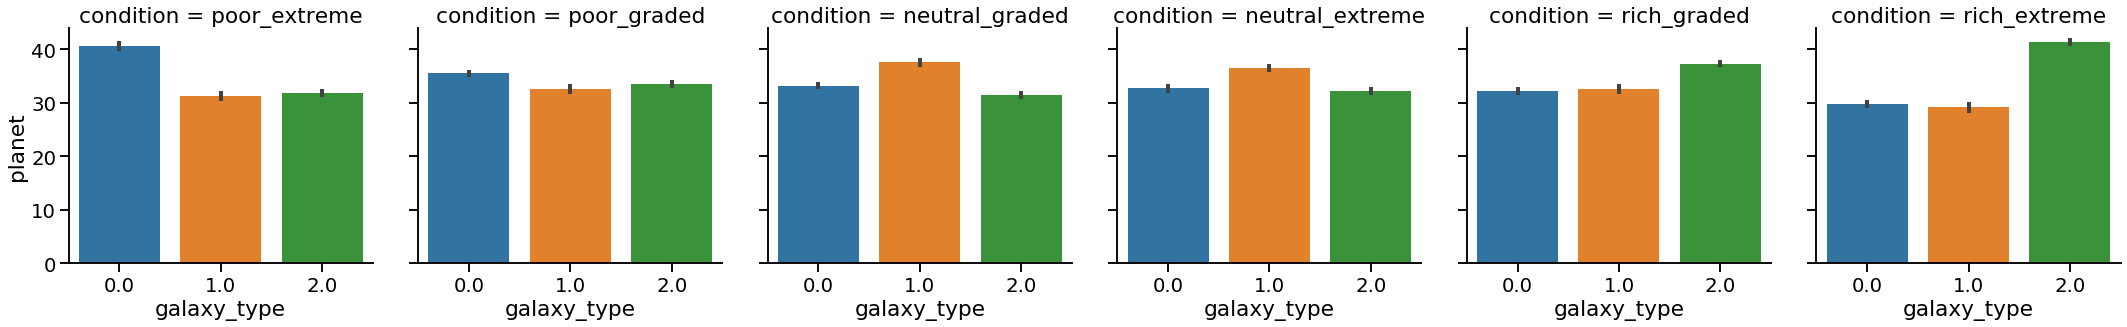

In [129]:
sns.catplot(x='galaxy_type',y='planet',col='condition',kind='bar',col_order = ['poor_extreme','poor_graded']+all_conds[2:],data=n_plan)
plt.savefig('../plots/number_of_planets')

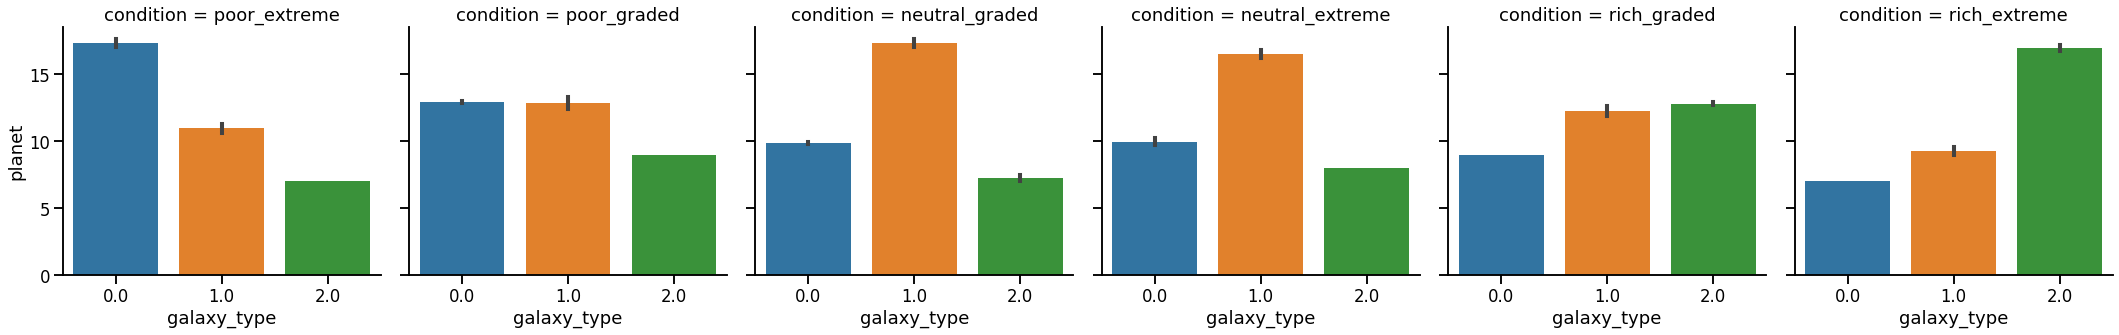

In [141]:
early_prts = prts.loc[prts['block']<2]
n_plan_early = early_prts.groupby(by=['condition','galaxy_type','n_sim']).planet.count().reset_index()
sns.catplot(x='galaxy_type',y='planet',col='condition',kind='bar',col_order = ['poor_extreme','poor_graded']+all_conds[2:],data=n_plan_early)
plt.savefig('../plots/number_of_planets_early.png')

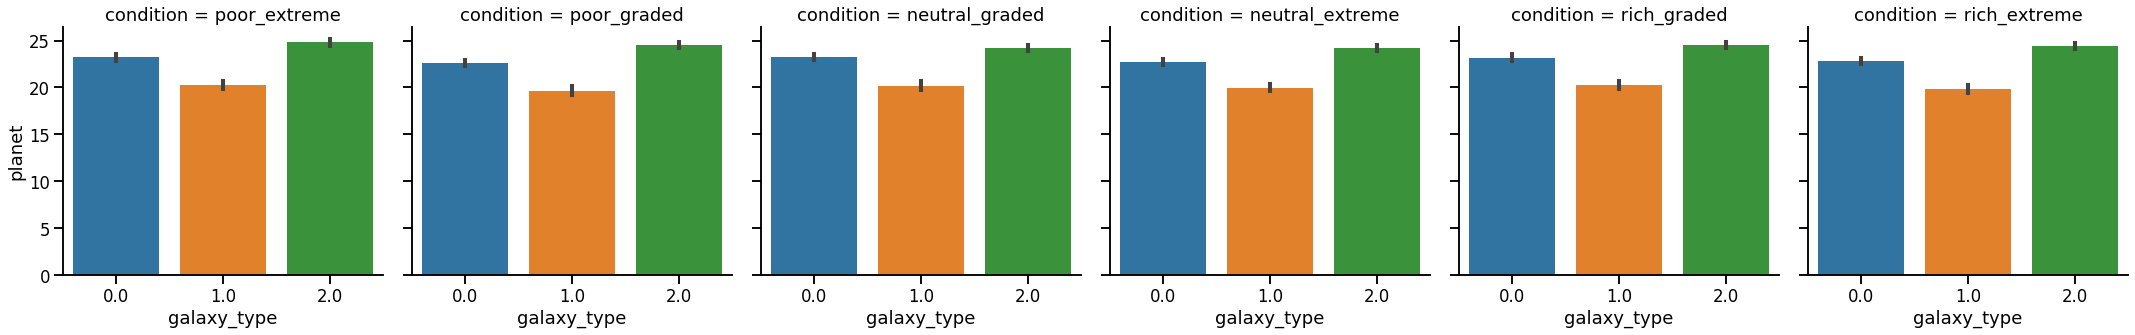

In [142]:
late_prts = prts.loc[prts['block']>=2]
n_plan_late = late_prts.groupby(by=['condition','galaxy_type','n_sim']).planet.count().reset_index()
sns.catplot(x='galaxy_type',y='planet',col='condition',kind='bar',col_order = ['poor_extreme','poor_graded']+all_conds[2:],data=n_plan_late)
plt.savefig('../plots/number_of_planets_late.png')

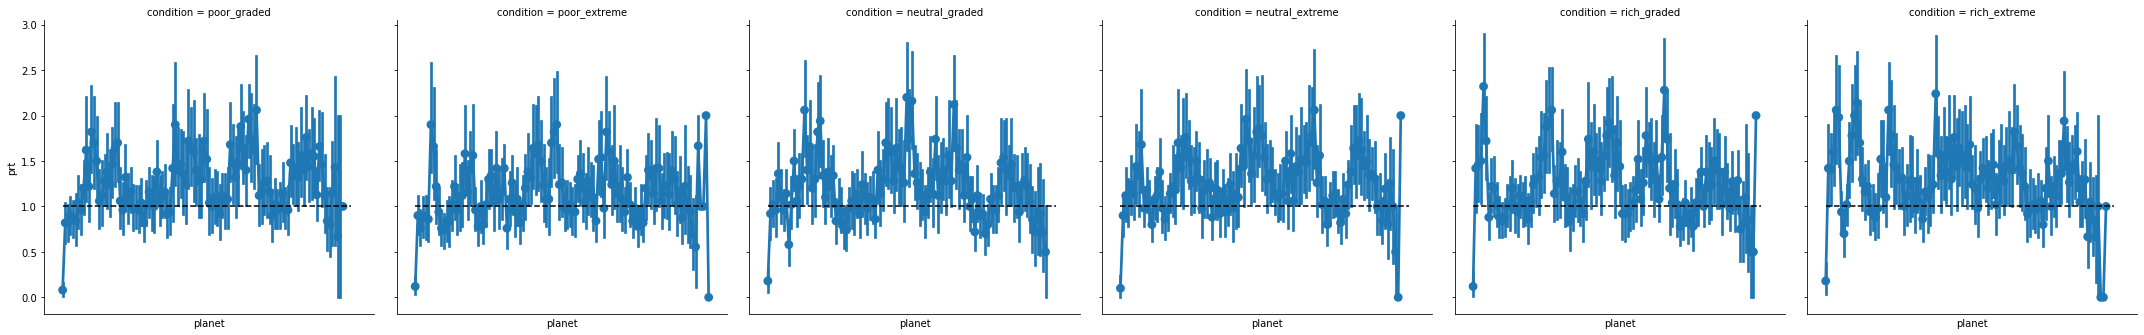

In [112]:
g=sns.catplot(x='planet',y='prt',col='condition',kind='point',data=prts)

for i in range(len(all_conds)):
    g.axes[0][i].plot([0,110],[1,1],'k--')
    g.axes[0][i].set_xticks([])